# ❤️ Heart Disease Diagnostic Analysis
**Author:** Eshmeet Singh  
**Date:** 2025  
**Domain:** Healthcare / Predictive Analytics  
**Data Source:** [Kaggle - Heart Failure Prediction Dataset](https://www.kaggle.com/fedesoriano/heart-failure-prediction)

---

## 📌 Project Overview
Cardiovascular diseases (CVDs) are the number 1 cause of death globally, taking an estimated 17.9 million lives each year, which accounts for 31% of all deaths worldwide. Heart failure is a common event caused by CVDs, and this dataset contains 11 features that can be used to predict a possible heart disease.

People with cardiovascular disease or who are at high cardiovascular risk (due to the presence of one or more risk factors such as hypertension, diabetes, hyperlipidaemia or already established disease) need early detection and management wherein a machine learning model can be of great help.

## 🎯 Objectives
1. **Data Cleaning:** Handle physiological anomalies (e.g., zero cholesterol) and missing values.
2. **EDA:** Uncover key risk factors using custom Univariate & Multivariate analysis functions.
3. **Modeling:** Benchmark classifiers (Logistic Regression, Random Forest, etc.) to maximize prediction accuracy.

## 📂 Attribute Information
| Feature | Description |
| :--- | :--- |
| **Age** | Age of the patient [years] |
| **Sex** | Sex of the patient [M: Male, F: Female] |
| **ChestPainType** | [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic] |
| **RestingBP** | Resting blood pressure [mm Hg] |
| **Cholesterol** | Serum cholesterol [mm/dl] |
| **FastingBS** | Fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise] |
| **RestingECG** | [Normal: Normal, ST: having ST-T wave abnormality, LVH: showing probable left ventricular hypertrophy] |
| **MaxHR** | Maximum heart rate achieved [Numeric value between 60 and 202] |
| **ExerciseAngina** | Exercise-induced angina [Y: Yes, N: No] |
| **Oldpeak** | ST depression induced by exercise relative to rest [Numeric value] |
| **ST_Slope** | The slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping] |
| **HeartDisease** | Output class [1: heart disease, 0: Normal] |

# Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 1. Global Configuration
warnings.filterwarnings('ignore') # Silence annoying warnings
pd.set_option('display.max_columns', None) # Show all columns

# 2. Visual Theme (Solves the "faded" look)
sns.set_theme(style="whitegrid", palette="muted") # Clean, professional grid
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120 # High resolution plots
plt.rcParams['font.weight'] = 'bold' # Readable fonts
plt.rcParams['axes.labelweight'] = 'bold'

In [2]:
df = pd.read_csv('Datasets/heart.csv')

# Initial Exploration and Cleaning

In [3]:
df.shape

(918, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df.sample(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
203,31,F,ATA,100,219,0,ST,150,N,0.0,Up,0
578,57,M,ASY,156,173,0,LVH,119,Y,3.0,Down,1
485,63,M,ATA,139,217,1,ST,128,Y,1.2,Flat,1
893,57,M,ATA,154,232,0,LVH,164,N,0.0,Up,1
901,58,F,ASY,170,225,1,LVH,146,Y,2.8,Flat,1


In [6]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['FastingBS'].unique()

array([0, 1])

📋 Data Correction: FastingBS
The `FastingBS` (Fasting Blood Sugar) column is currently stored as numbers (`0` and `1`), but it actually represents two groups:
* **0:** Normal Blood Sugar
* **1:** High Blood Sugar (> 120 mg/dl)

We will convert this to a categorical format so our plots treat them as separate groups rather than a numerical scale.

In [10]:
df['FastingBS'] = df['FastingBS'].astype('object')

⚠️ Data Integrity Check: Hidden Missing Values
* **Issue:** We detected `0` values in `RestingBP` (Blood Pressure) and `Cholesterol`.
* **Physiological Context:** A value of 0 is medically impossible for a living patient, indicating these are actually **missing values** encoded as zeros.
* **Resolution:** We will mark these as `NaN` and impute them with the **median** to preserve the data distribution without introducing bias. 

In [11]:
#Replacing zeroes with nan to create missing values
df_clean = df.copy()
df_clean['Cholesterol'] = df_clean['Cholesterol'].replace(0, np.nan)
df_clean['RestingBP'] = df_clean['RestingBP'].replace(0, np.nan)

In [12]:
#TTS
from sklearn.model_selection import train_test_split
X = df_clean.drop(['HeartDisease'], axis = 1)
y = df_clean['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [13]:
#Imputing 0 values with median
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy = 'median')
imputer.fit(X_train[['Cholesterol', 'RestingBP']])

X_train[['Cholesterol', 'RestingBP']] = imputer.transform(X_train[['Cholesterol', 'RestingBP']])
X_test[['Cholesterol', 'RestingBP']] = imputer.transform(X_test[['Cholesterol', 'RestingBP']])

In [14]:
cat_col = X_train.select_dtypes('object').columns
num_col = X_train.columns.to_list()

for col in cat_col:
    num_col.remove(col)

temp_df = pd.concat([X_train[num_col], y_train], axis = 1)

print(temp_df.corr()['HeartDisease'])

Age             0.299410
RestingBP       0.152906
Cholesterol     0.053278
MaxHR          -0.414676
Oldpeak         0.422740
HeartDisease    1.000000
Name: HeartDisease, dtype: float64


🔍 Initial Data & Correlation Check
* **Data Quality:** Confirmed there are **no duplicate rows**, ensuring the integrity of our dataset.
* **Correlation Analysis:** The 5 numerical features show only moderate correlation with the target.
    * *Insight:* The lack of extremely strong linear correlation suggests that heart disease prediction is complex and likely depends on **non-linear interactions** between features, motivating the use of models like Random Forest later.

# EDA

## Univariate Analysis

In [15]:
#Defining Functions to autoplot some graphs for analysis
def UniAnalyse_Num(df, col):
    """
    Visualizes the distribution of a numerical column using a Histogram and Boxplot.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Histogram with KDE
    sns.histplot(df[col], bins=20, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribution of {col}')
    
    # Plot 2: Boxplot for Outliers
    sns.boxplot(x=df[col], ax=axes[1], color='orange')
    axes[1].set_title(f'Boxplot of {col}')
    
    plt.show()

def UniAnalyse_Cat(df, col, target):
    """
    Visualizes a categorical column with 3 fixed plots:
    1. Distribution (Count)
    2. Relation with Target (Heart Disease)
    3. Percentage Split
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Overall Count
    sns.countplot(data=df, x=col, hue=col, ax=axes[0], palette='pastel', legend=False)
    axes[0].set_title(f'{col} Distribution')
    
    # Plot 2: Relation with Target (No if-condition needed now)
    sns.countplot(data=df, x=col, hue=target, ax=axes[1], palette='bright')
    axes[1].set_title(f'{col} vs Heart Disease')
    
    # Plot 3: Pie Chart
    df[col].value_counts().plot(kind='pie', autopct='%.1f%%', ax=axes[2], ylabel='')
    axes[2].set_title(f'{col} Percentage')
    
    plt.tight_layout()
    plt.show()

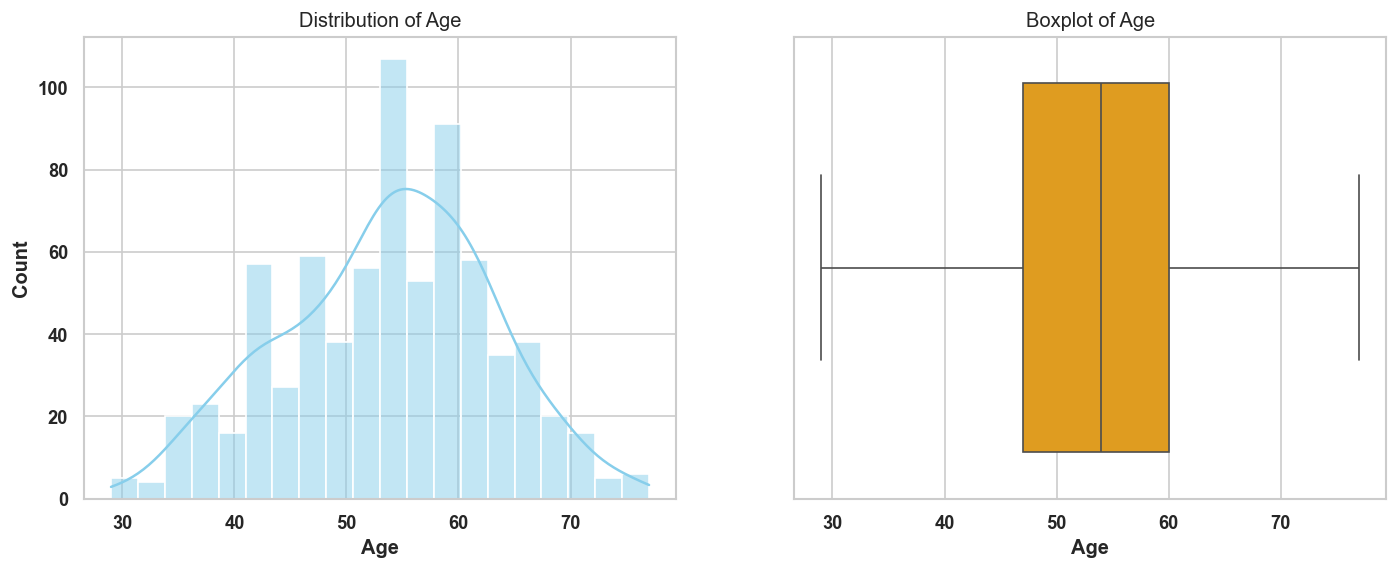

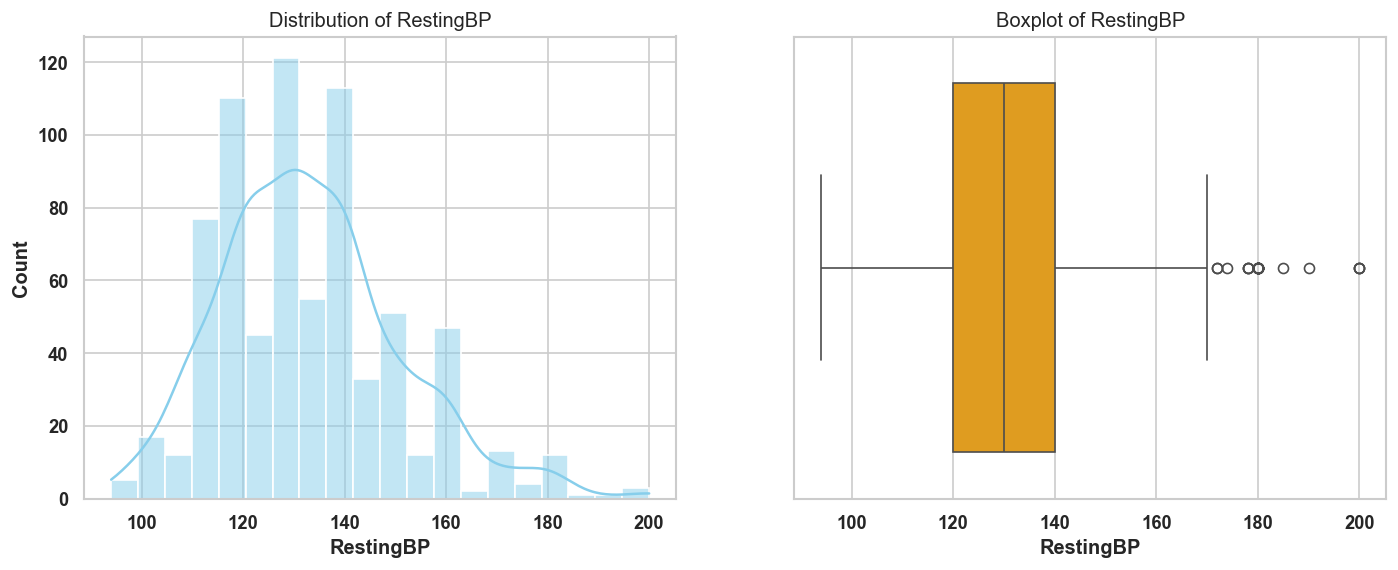

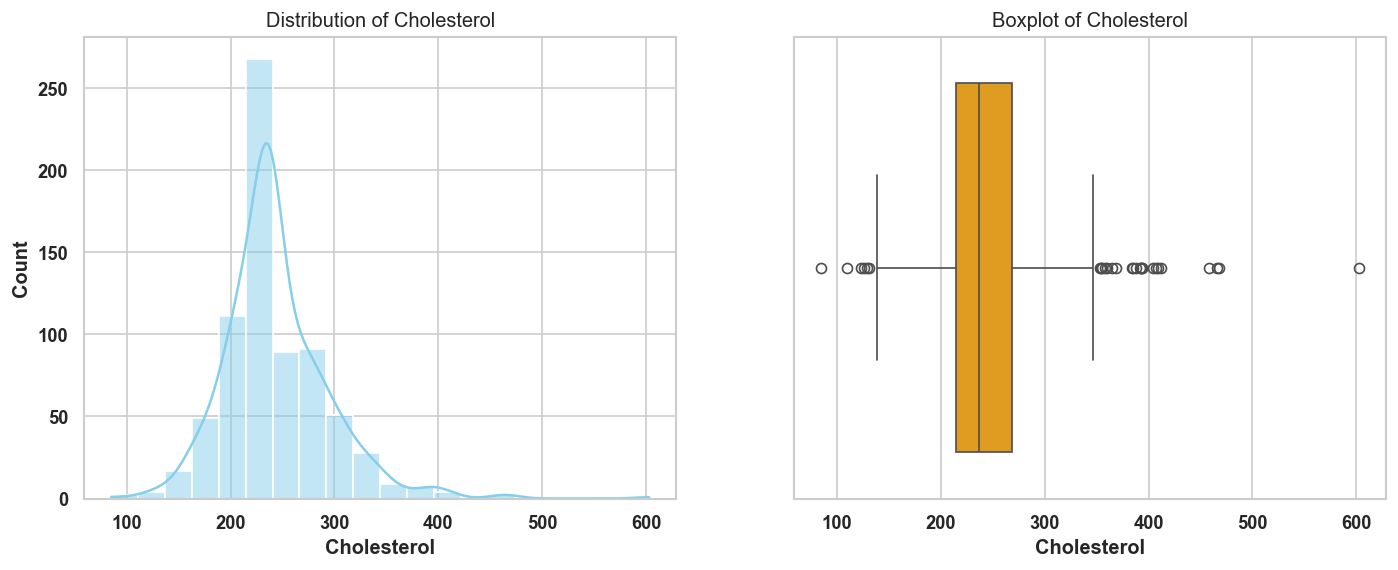

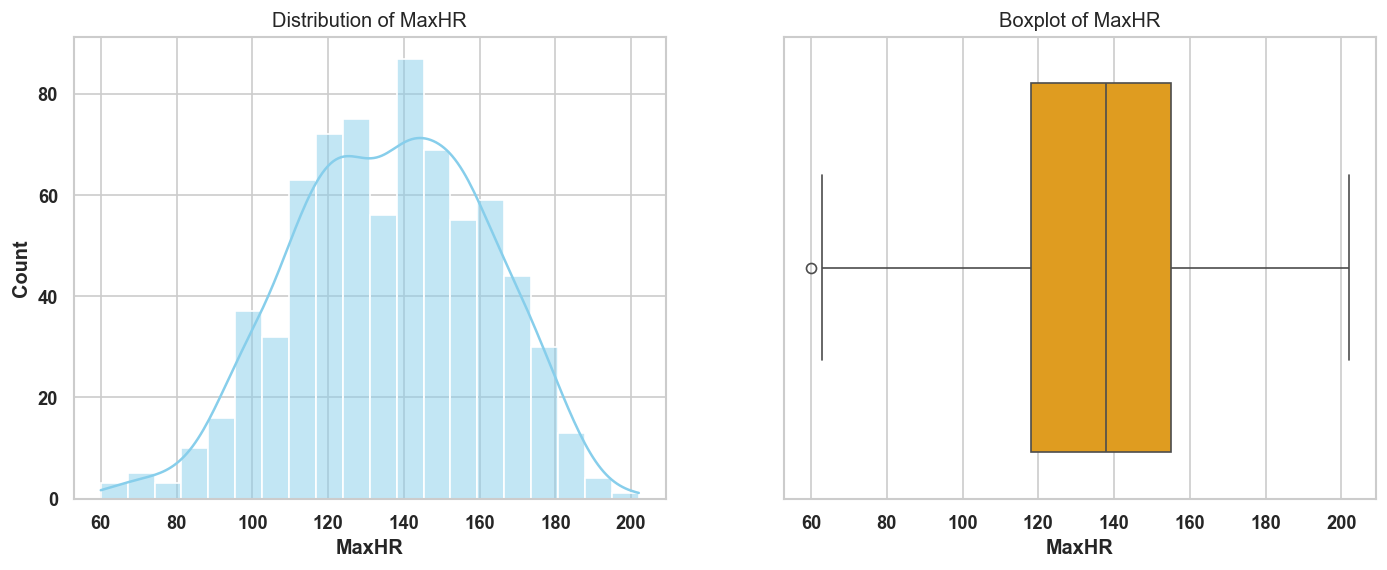

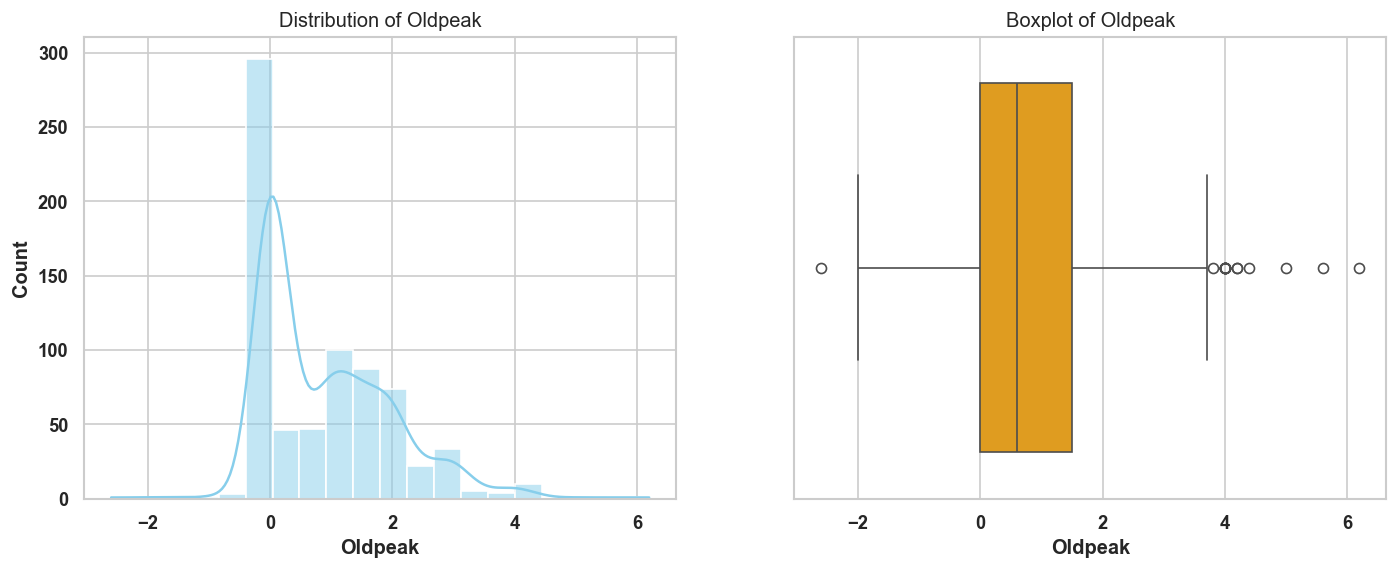

In [16]:
#Analysing numerical columns
for col in num_col:
    UniAnalyse_Num(X_train, col)

In [17]:
X_train[num_col].skew()

Age           -0.180105
RestingBP      0.634786
Cholesterol    1.231932
MaxHR         -0.164850
Oldpeak        1.046324
dtype: float64

📊 Distribution Analysis
* **Skewness Detected:** The features `RestingBP`, `Cholesterol`, and `Oldpeak` are **positively skewed** (leaning heavily to the right).
    * **Action:** We apply a **Power Transformer** (Yeo-Johnson) to fix this. This "un-skews" the data into a normal distribution, preventing our models from being biased by extreme values.
* **Feature Stability:** The `Age` feature shows **no outliers** and follows a standard bell curve, making it a stable baseline for prediction.

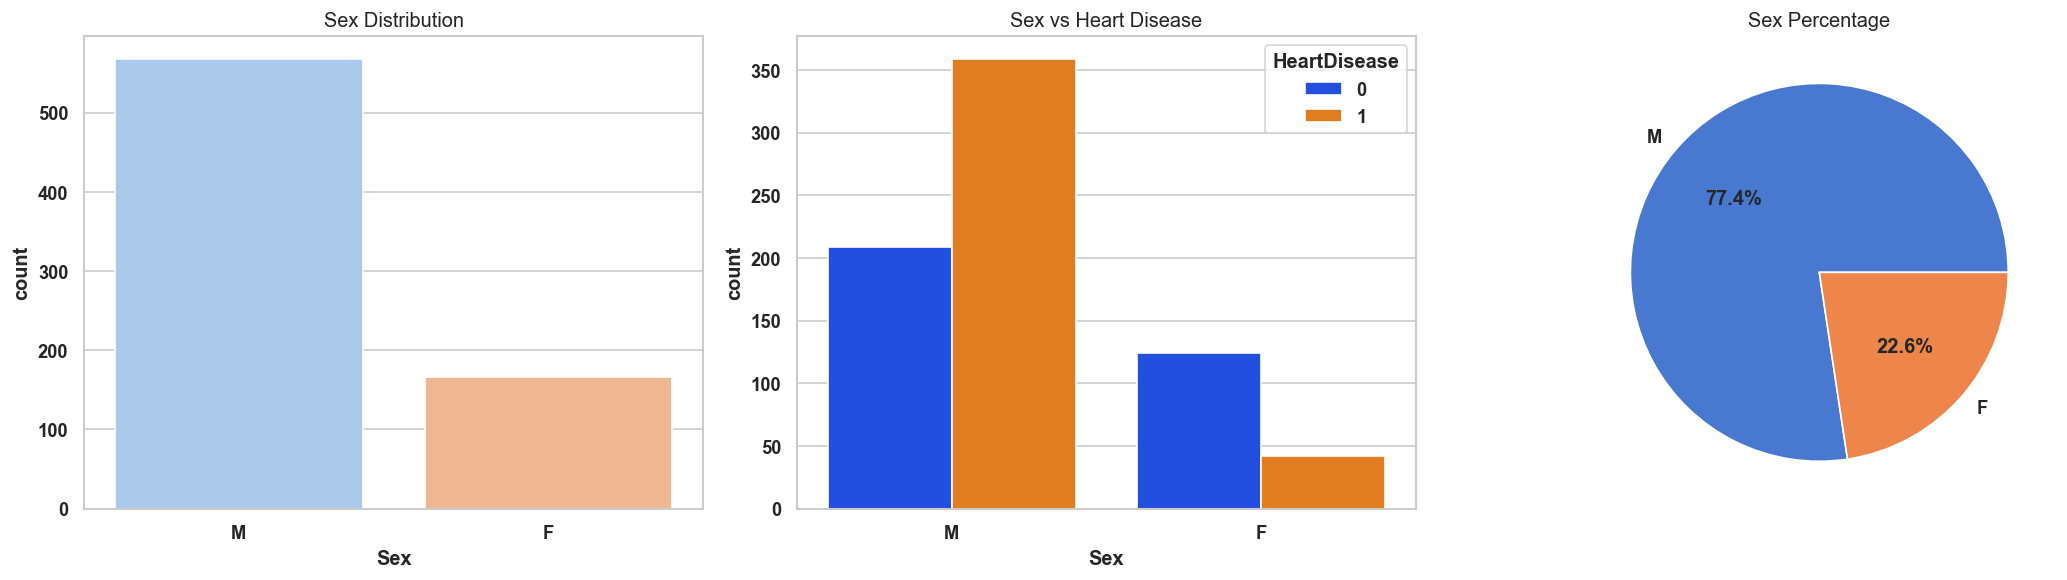

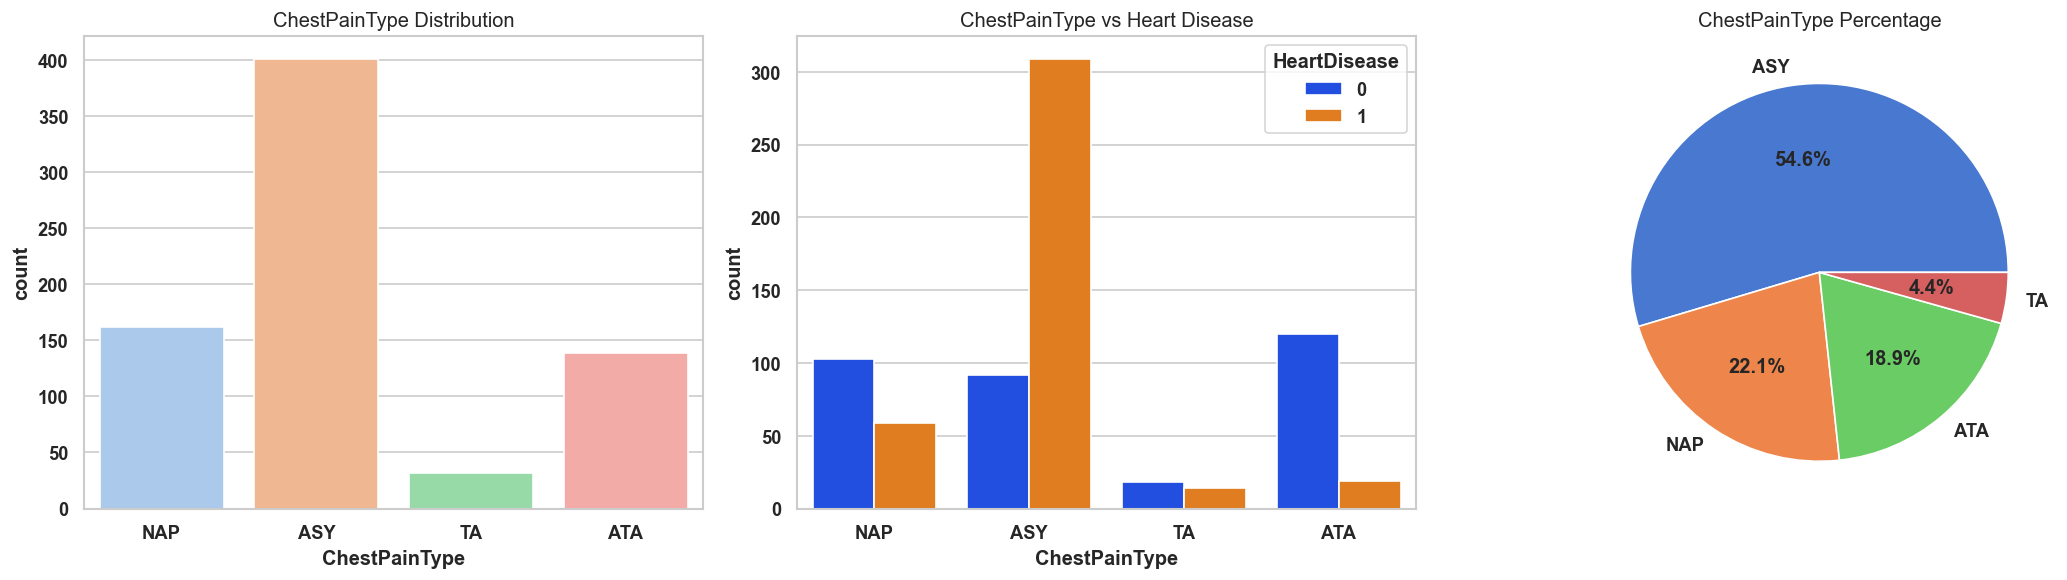

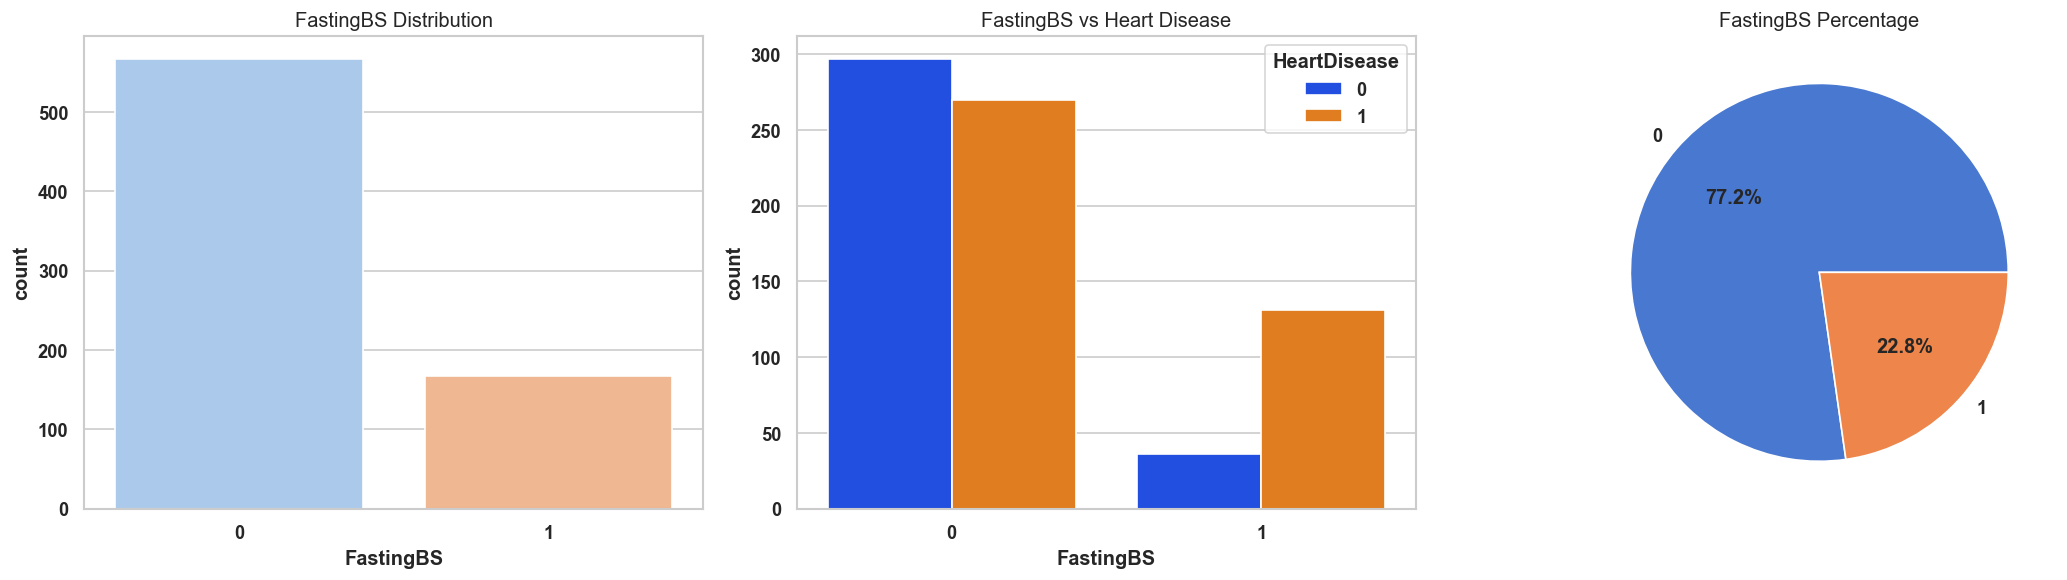

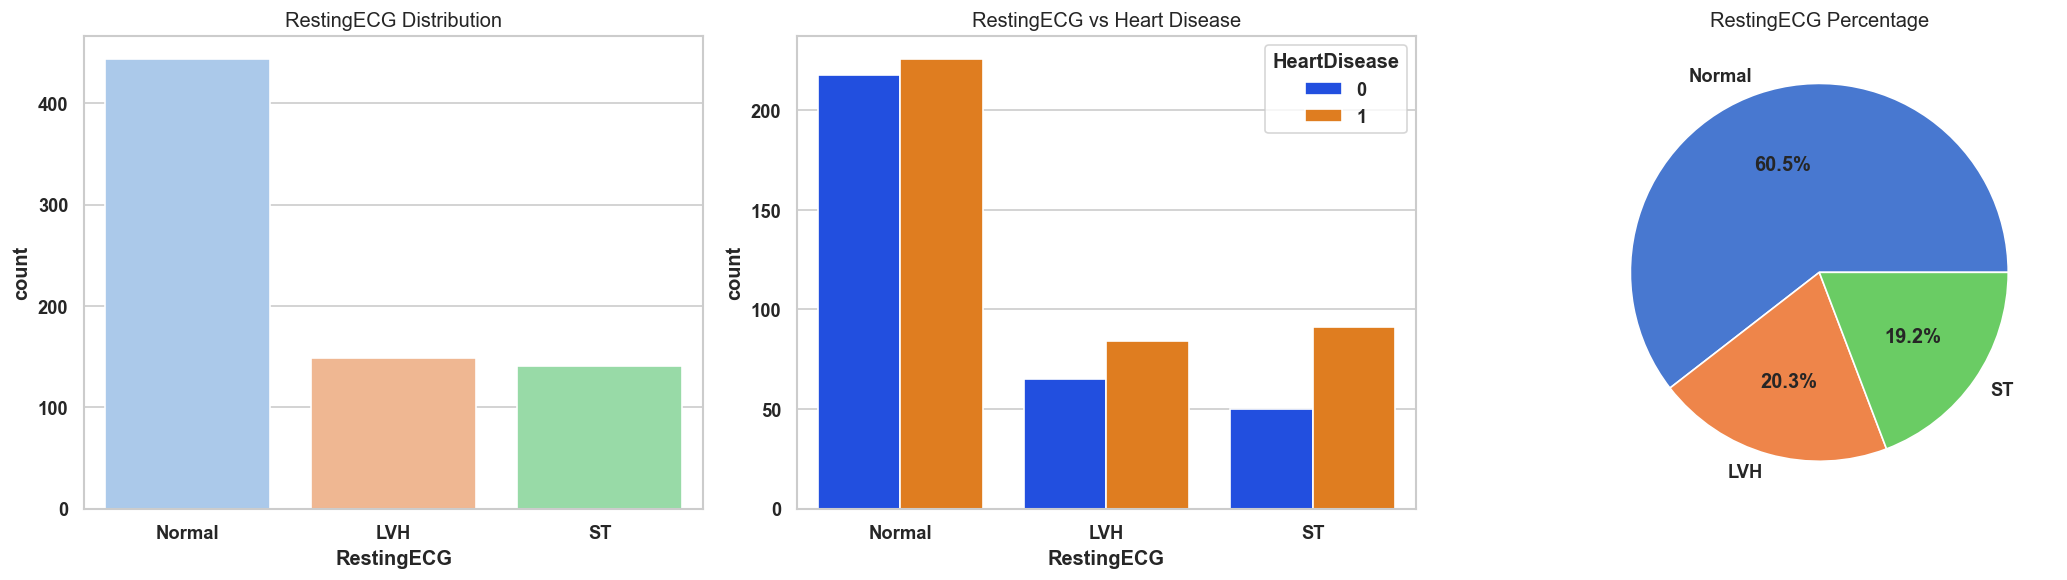

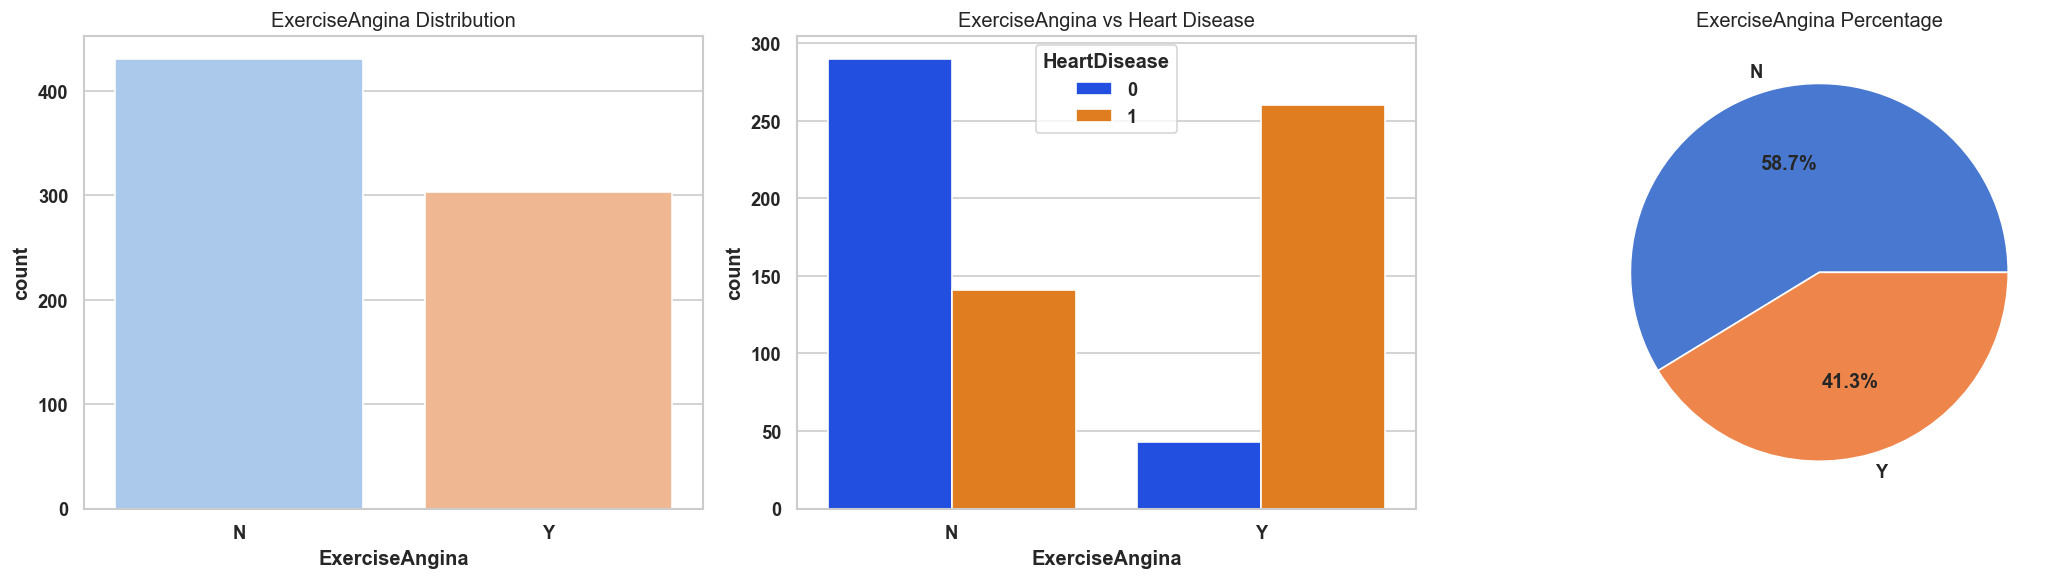

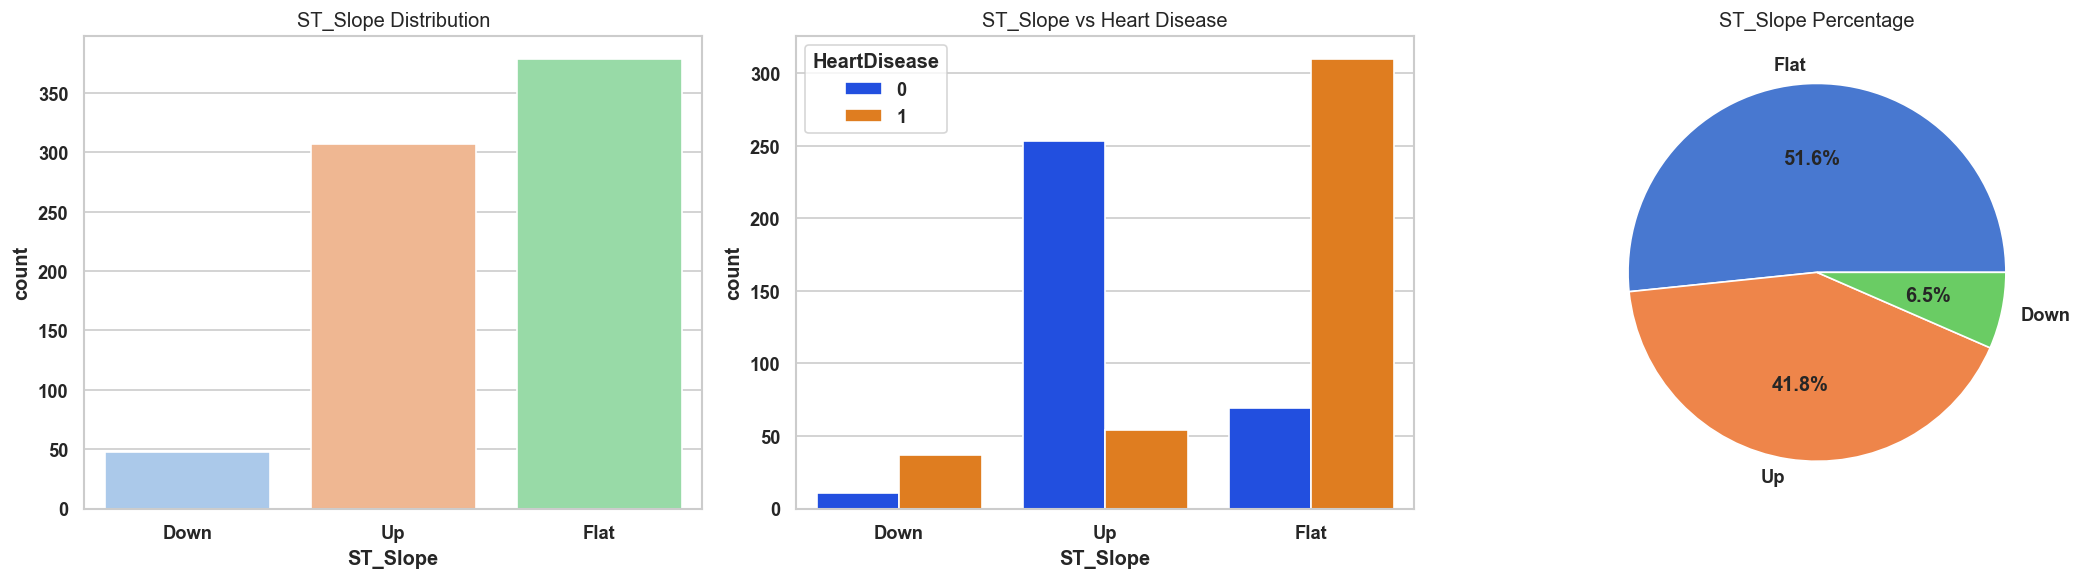

In [18]:
#Analysing Categorical Columns
for col in cat_col:
    temp_df = pd.concat([X_train, y_train], axis=1)
    UniAnalyse_Cat(temp_df, col, target='HeartDisease')

In [19]:
#Calculating HeartDisease Probability for each categorical columns' category
temp_cat_df = pd.concat([X_train[cat_col], y_train], axis=1)

for col in cat_col:
    print(f'HeartDisease Probability(%) in the Categories of {col}: \n')
    print(temp_cat_df.groupby(col)['HeartDisease'].mean() * 100)
    print('\n')

HeartDisease Probability(%) in the Categories of Sex: 

Sex
F    25.301205
M    63.204225
Name: HeartDisease, dtype: float64


HeartDisease Probability(%) in the Categories of ChestPainType: 

ChestPainType
ASY    77.057357
ATA    13.669065
NAP    36.419753
TA     43.750000
Name: HeartDisease, dtype: float64


HeartDisease Probability(%) in the Categories of FastingBS: 

FastingBS
0    47.619048
1    78.443114
Name: HeartDisease, dtype: float64


HeartDisease Probability(%) in the Categories of RestingECG: 

RestingECG
LVH       56.375839
Normal    50.900901
ST        64.539007
Name: HeartDisease, dtype: float64


HeartDisease Probability(%) in the Categories of ExerciseAngina: 

ExerciseAngina
N    32.714617
Y    85.808581
Name: HeartDisease, dtype: float64


HeartDisease Probability(%) in the Categories of ST_Slope: 

ST_Slope
Down    77.083333
Flat    81.794195
Up      17.589577
Name: HeartDisease, dtype: float64




💡 Critical Insights: Risk Factors

* **Gender Differences:** Men are significantly more likely to have heart disease in this dataset compared to women.
* **Symptom Analysis:**
    * **The "Silent" Risk:** Surprisingly, patients with **Asymptomatic** chest pain (no pain at all) had the highest rate of heart disease. This suggests that feeling "fine" doesn't always mean you are safe.
    * **Exercise Pain:** Pain triggered by exercise (Exercise Angina) is a major red flag and is highly linked to heart disease.
* **Clinical Tests:**
    * **ST Slope:** An **Upward** slope is usually a sign of a healthy heart. A **Flat or Down** slope is a strong warning sign.
    * **Blood Sugar:** High Fasting Blood Sugar (>120 mg/dl) acts as a "risk multiplier," especially when combined with other symptoms.

## Multivariate Analysis

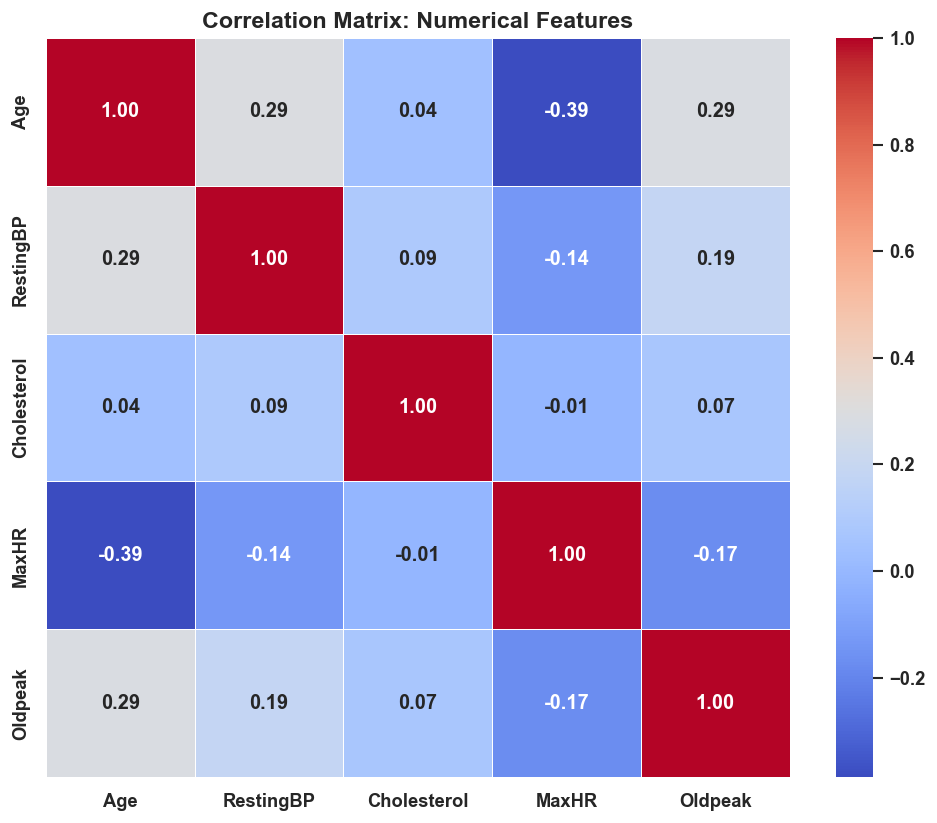

In [20]:
# Correlation Matrix of Numerical Features
plt.figure(figsize=(10, 8))
sns.heatmap(X_train[num_col].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: Numerical Features', fontsize=14, fontweight='bold')
plt.show()

📉 Correlation Analysis
* **Age & Max Heart Rate:** We observe a slight negative correlation. This aligns with medical expectation: as patients age, their maximum achievable heart rate naturally decreases.
* **Feature Independence:** Overall, the numerical features do not show strong correlations with each other.
    * **Impact:** This is positive for our models (especially Logistic Regression), as it implies the features provide unique, non-redundant information. 

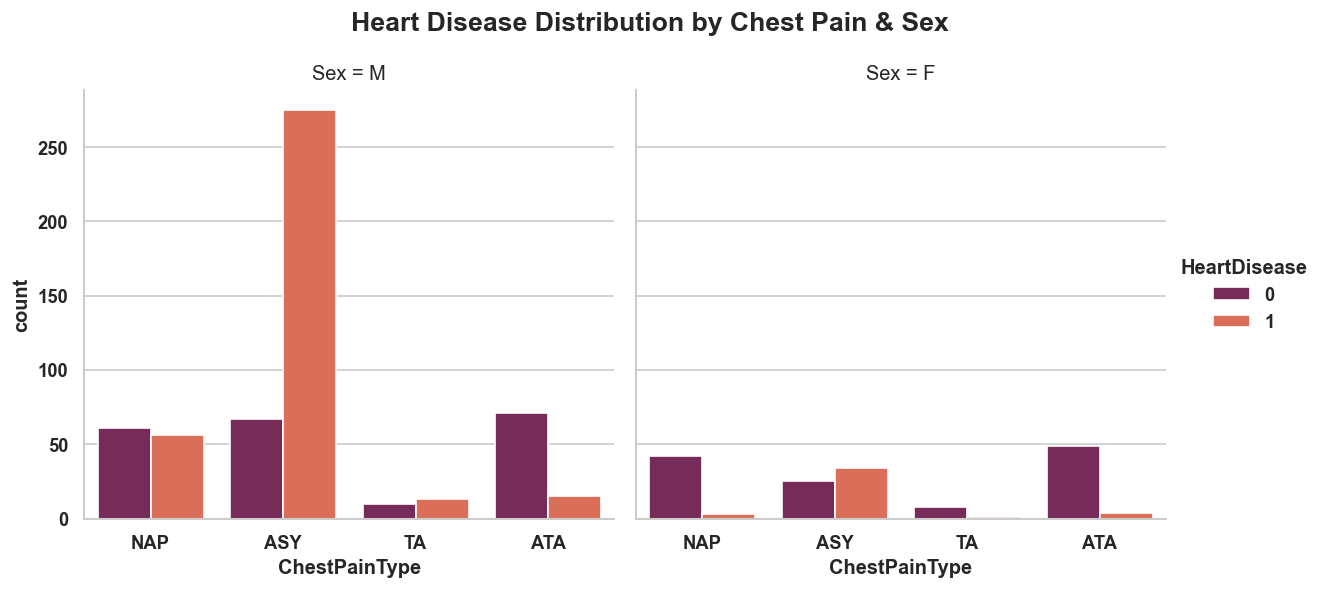

In [21]:
#Insight 1: How ChestPainType and Sex affect Heart Disease chances?
g = sns.catplot(data = pd.concat([X_train, y_train], axis = 1), x = 'ChestPainType', hue = 'HeartDisease', col = 'Sex', kind = 'count', height = 5, aspect = 1, palette = 'rocket')
g.fig.subplots_adjust(top = 0.85)
g.fig.suptitle('Heart Disease Distribution by Chest Pain & Sex', fontsize = 16, fontweight = 'bold')
plt.show()

💡 Key Insight: Chest Pain & Gender
* **The "Silent" Risk:** **Asymptomatic (ASY)** chest pain is the leading predictor of heart disease for both sexes. This implies that the *absence* of pain does not guarantee a healthy heart.
* **Gender Volume:** While the risk pattern is similar, men in this dataset experience a much higher volume of chest pain events compared to women.

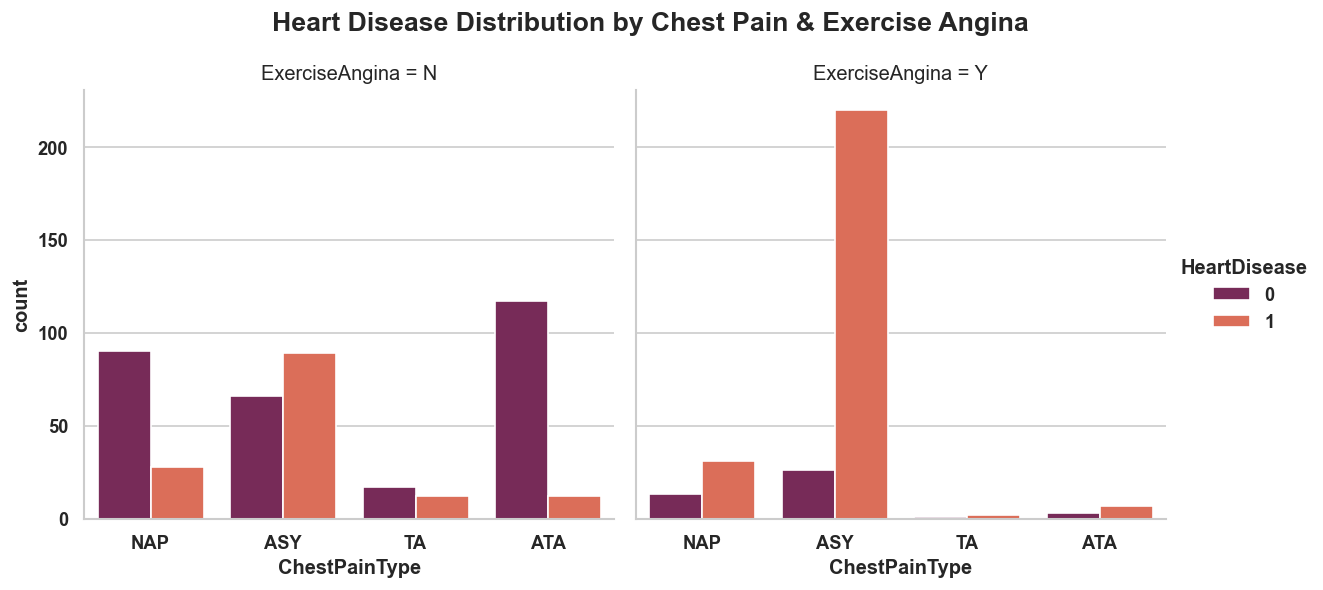

In [22]:
#Insight 2: How ChestPainType and ExerciseAngina affect Heart Disease chances?
g = sns.catplot(data = pd.concat([X_train, y_train], axis = 1), x = 'ChestPainType', hue = 'HeartDisease', col = 'ExerciseAngina', kind = 'count', height = 5, aspect = 1, palette = 'rocket')
g.fig.subplots_adjust(top = 0.85)
g.fig.suptitle('Heart Disease Distribution by Chest Pain & Exercise Angina', fontsize = 16, fontweight = 'bold')
plt.show()

💡 Key Insight: Exercise Angina & Chest Pain
* **Symptom Overlap:** Patients with **Exercise Angina** overwhelmingly present with **Asymptomatic (ASY)** chest pain, while rarely reporting other pain types (like Atypical Angina).
* **Risk Amplification:** The presence of Exercise Angina acts as a "risk multiplier." If a patient has Exercise Angina, their probability of Heart Disease increases significantly, **regardless** of what specific type of chest pain they report.

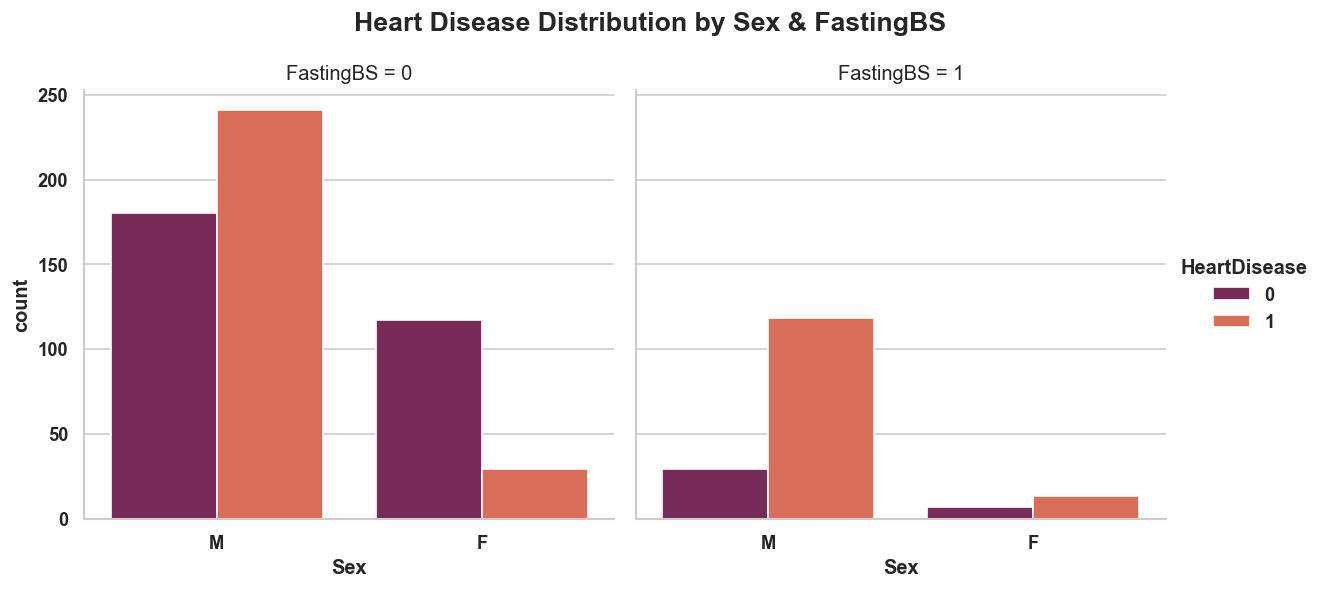

In [23]:
#Insight 3: How FastingBS and Sex relate to HeartDiseases?
g = sns.catplot(data = pd.concat([X_train, y_train], axis = 1), x = 'Sex', hue = 'HeartDisease', col = 'FastingBS', kind = 'count', height = 5, aspect = 1, palette = 'rocket')
g.fig.subplots_adjust(top = 0.85)
g.fig.suptitle('Heart Disease Distribution by Sex & FastingBS', fontsize = 16, fontweight = 'bold')
plt.show()

💡 Key Insight: Fasting Blood Sugar (FastingBS) & Gender
* **Low Risk Group:** Females with normal blood sugar (< 120 mg/dl) show a significantly lower probability of heart disease compared to the rest of the population.
* **High Risk Group:** For males, a Fasting Blood Sugar > 120 mg/dl is a critical warning sign. This group shows a very high correlation with positive heart disease diagnoses.

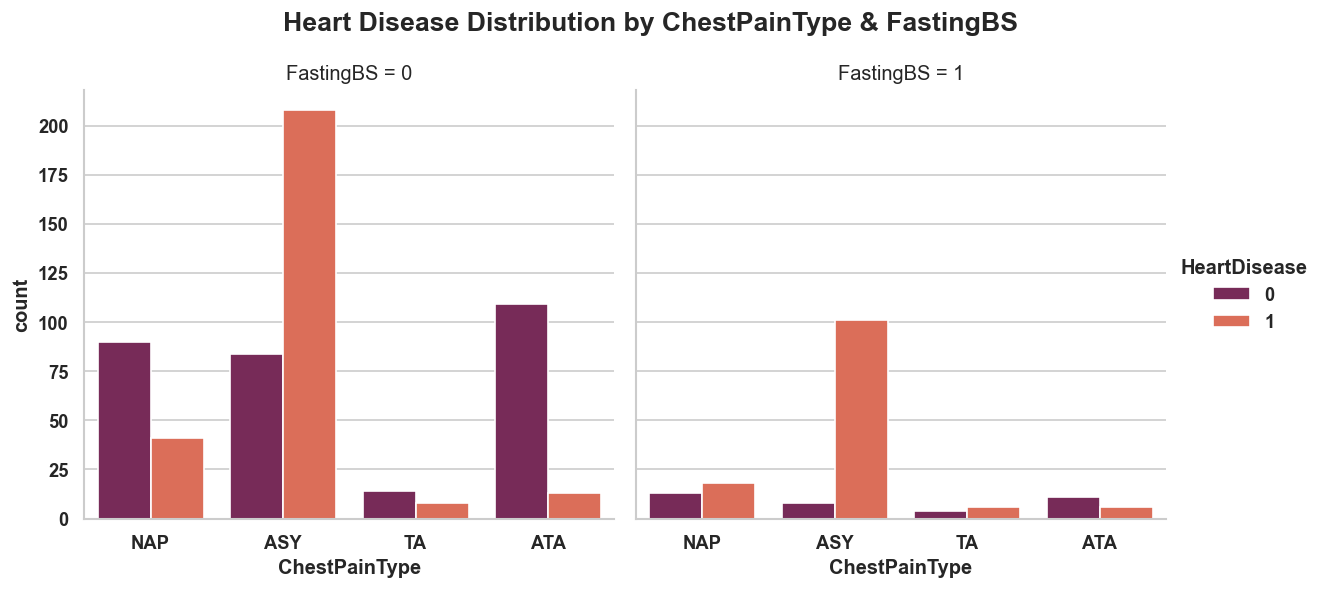

In [24]:
#Insight 4: How do ChestPainType and FastingBS related to HeartDisease?
g = sns.catplot(data = pd.concat([X_train, y_train], axis = 1), x = 'ChestPainType', hue = 'HeartDisease', col = 'FastingBS', kind = 'count', height = 5, aspect = 1, palette = 'rocket')
g.fig.subplots_adjust(top = 0.85)
g.fig.suptitle('Heart Disease Distribution by ChestPainType & FastingBS', fontsize = 16, fontweight = 'bold')
plt.show()

💡 Key Insight: Interaction of Blood Sugar & Chest Pain
* **Dominant Risk:** **Asymptomatic (ASY)** chest pain remains the strongest predictor of heart disease, regardless of whether the patient has high or normal Fasting Blood Sugar.
* **The "Multiplier" Effect:** Generally, high Fasting Blood Sugar (> 120 mg/dl) increases the likelihood of heart disease when combined with chest pain.
    * **Exception:** The **Atypical Angina (ATA)** group is an outlier; these patients maintain a lower risk profile even when their blood sugar is elevated.

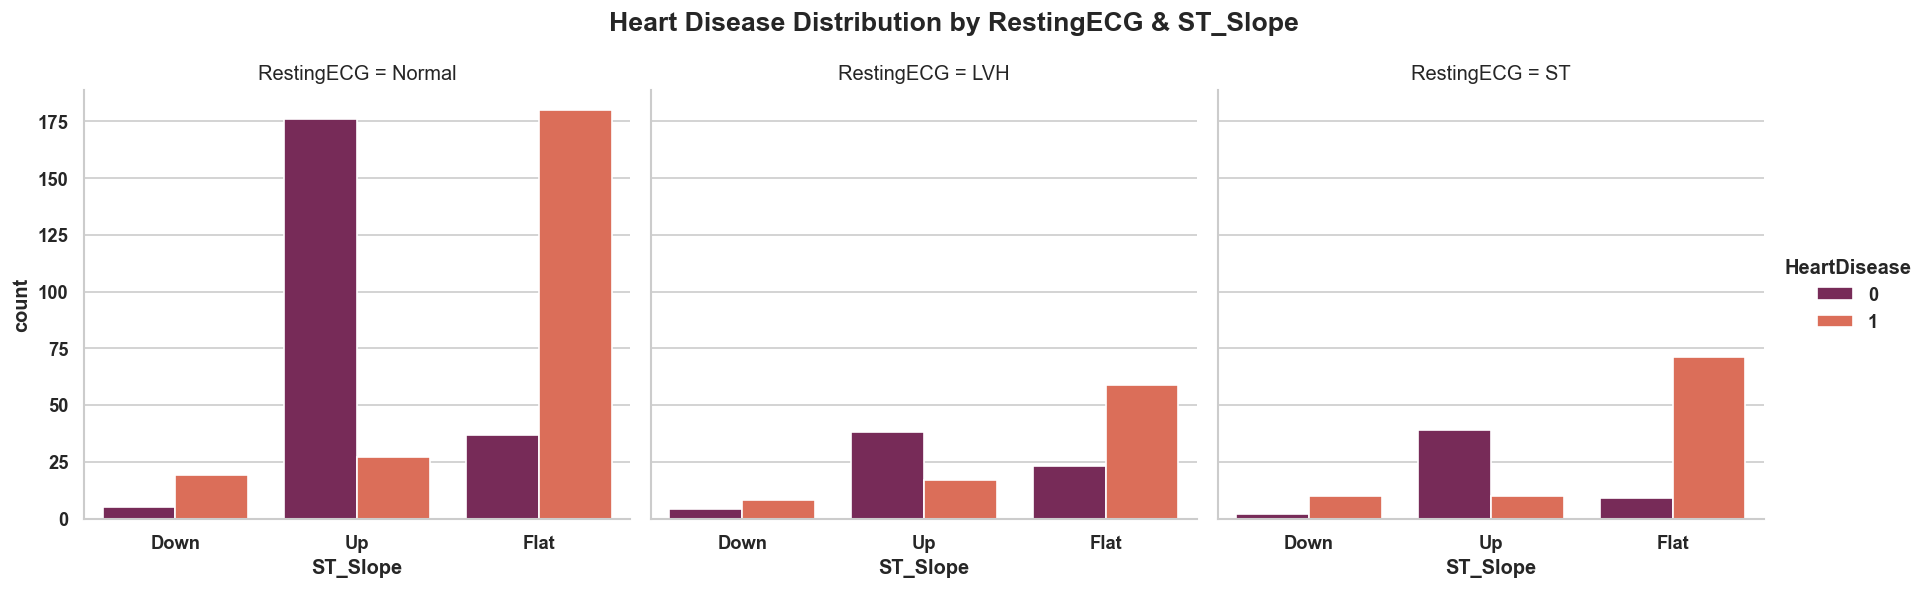

In [25]:
#Insight 5: How RestingECG and ST_Slope affect HeartDisease chances?
g = sns.catplot(data = pd.concat([X_train, y_train], axis = 1), x = 'ST_Slope', hue = 'HeartDisease', col = 'RestingECG', kind = 'count', height = 5, aspect = 1, palette = 'rocket')
g.fig.subplots_adjust(top = 0.85)
g.fig.suptitle('Heart Disease Distribution by RestingECG & ST_Slope', fontsize = 16, fontweight = 'bold')
plt.show()

💡 Key Insight: ST Slope & ECG Interaction
* **The "Healthy" Profile:** An **Upward** ST Slope is a strong indicator of a healthy heart (Green). This clean bill of health is further reinforced when the patient also has a **Normal RestingECG**.
* **The "High-Risk" Profile:** Conversely, a **Flat** ST Slope is a major warning sign. The probability of heart disease amplifies significantly when this is paired with **ST-Wave Abnormalities** in the ECG.

In [26]:
def Analyse_NumtoCat(df, num, cat, target='HeartDisease'):
    """
    Visualizes the relationship between a numerical and categorical feature,
    segmented by the target class.
    
    Plots:
    1. Boxplot (Distribution & Outliers)
    2. Violinplot (Density estimation)
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Boxplot
    sns.boxplot(ax=axes[0], data=df, x=cat, y=num, hue=target, palette='rocket')
    axes[0].set_title(f'{num} by {cat} (Boxplot)')
    
    # Plot 2: Violinplot (set split=True for a cleaner look comparing 2 classes)
    sns.violinplot(ax=axes[1], data=df, x=cat, y=num, hue=target, split=True, palette='rocket')
    axes[1].set_title(f'{num} by {cat} (Violinplot)')
    
    plt.tight_layout()
    plt.show()

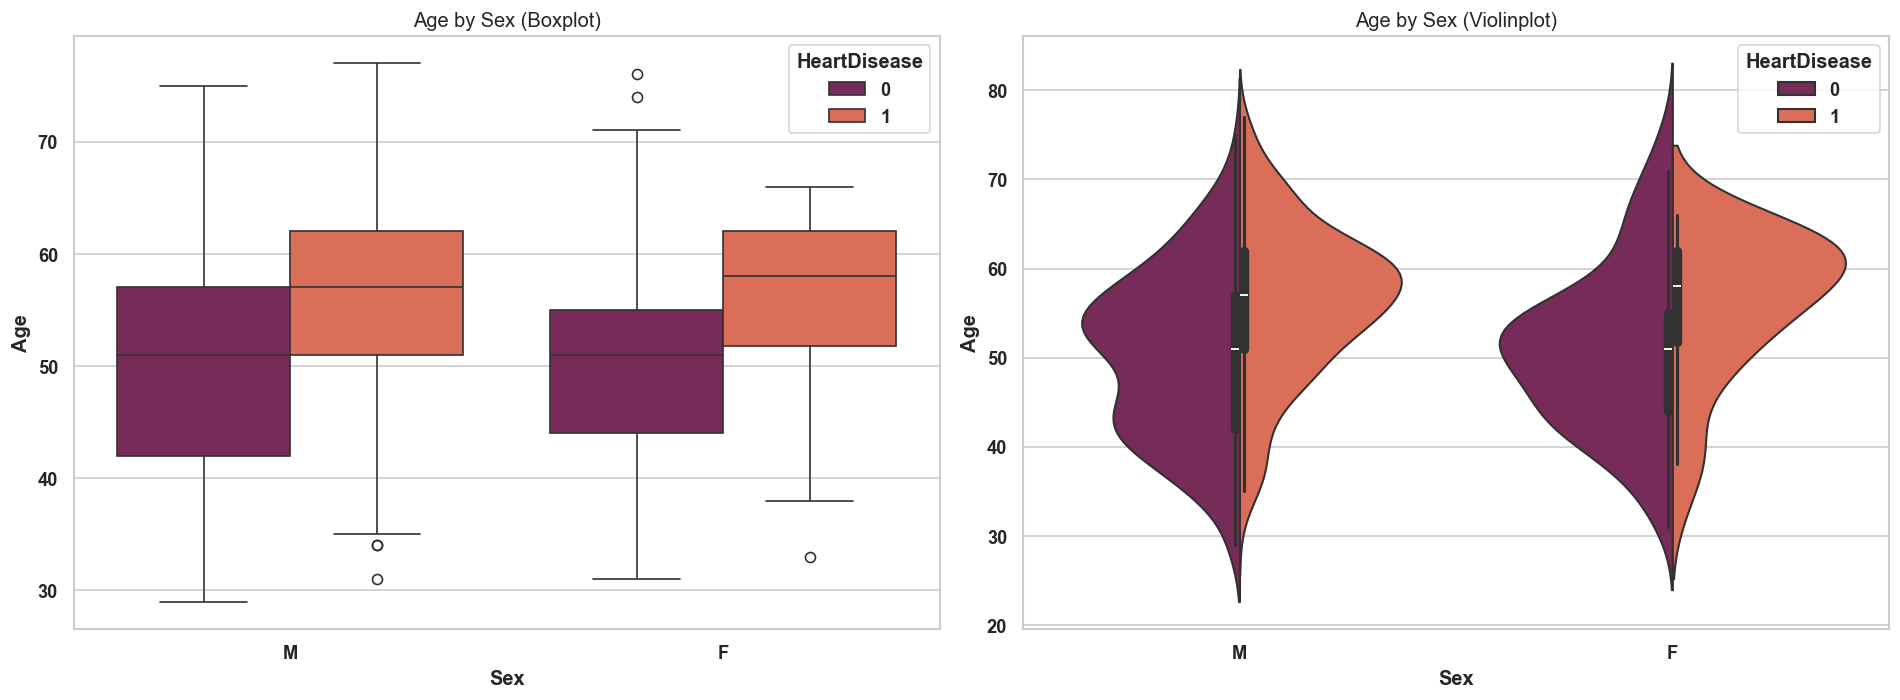

In [27]:
#Insight 6: How Age and Sex affect HeartDisease?
Analyse_NumtoCat(pd.concat([X_train, y_train], axis = 1), 'Age', 'Sex')

💡 Key Insight: Age & Gender Dynamics
* **Universal Risk Factor:** Older patients are significantly more likely to be diagnosed with heart disease compared to younger ones. This trend holds true for **both men and women**.
* **Consistency:** While men in this dataset have a higher overall count of heart disease, the *impact* of aging on heart health is consistent across both genders.

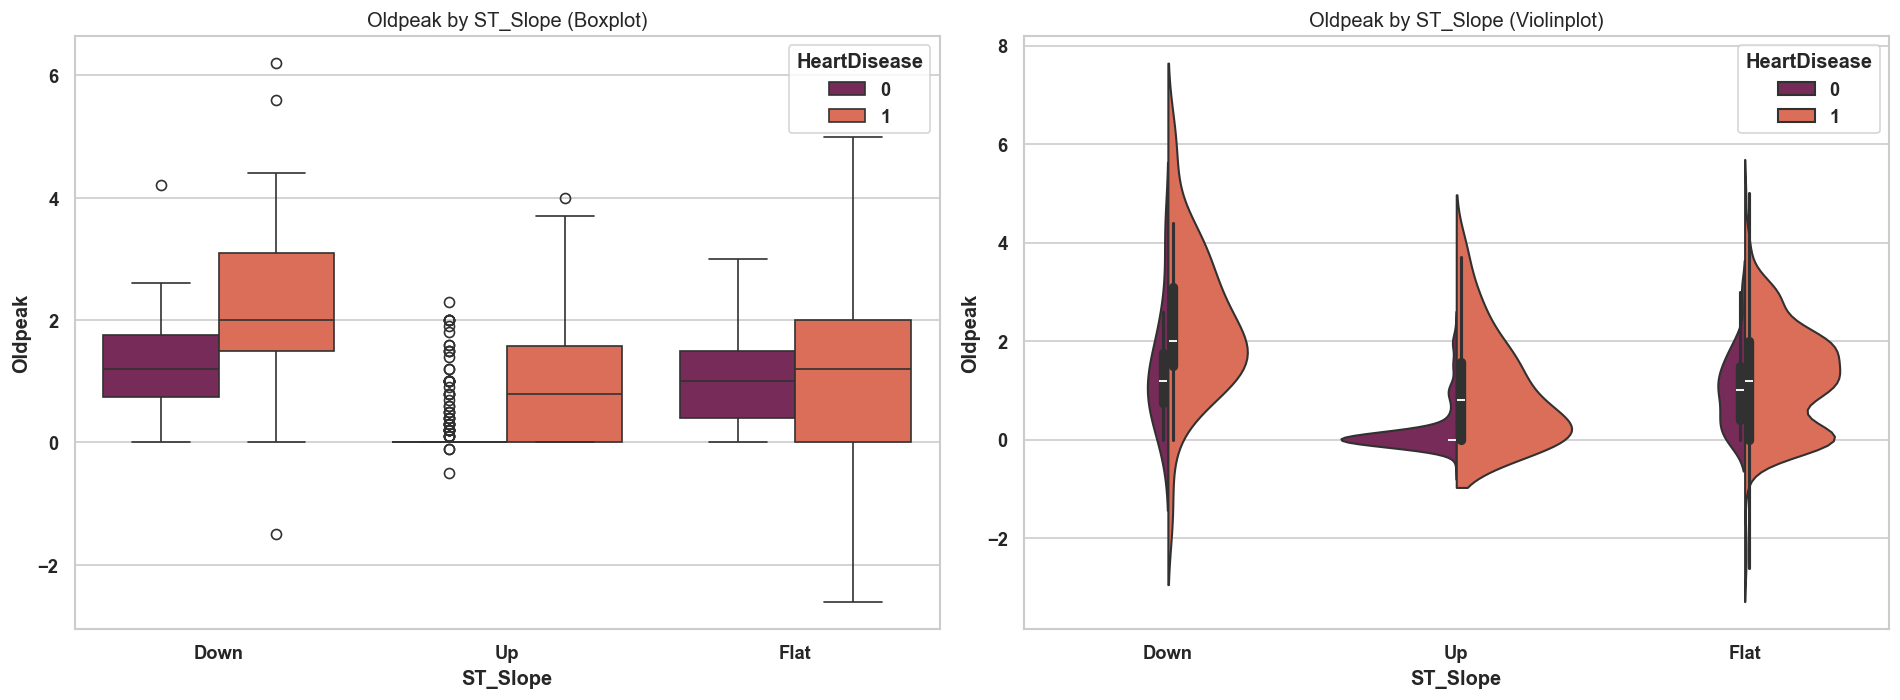

In [28]:
#Insight 7: How does Oldpeak and ST_Slope affect HeartDisease chances?
Analyse_NumtoCat(pd.concat([X_train, y_train], axis = 1), 'Oldpeak', 'ST_Slope')

💡 Key Insight: Oldpeak & ST Slope Interaction
* **The Healthy Baseline (Up Slope):** The combination of an **Up** slope and an **Oldpeak near 0** is the strongest marker of a healthy heart. Even among the few unhealthy patients with an Up slope, Oldpeak levels remain relatively low.
* **The "Gray Zone" (Flat Slope):** The **Flat** slope category presents a diagnostic challenge. There is significant overlap in Oldpeak values (0–2.5) between healthy and unhealthy patients, indicating that `Oldpeak` alone is less effective at distinguishing risk within this specific group.
* **Differentiation (Down Slope):** The **Down** slope offers clearer separation. Healthy patients in this category rarely show elevated Oldpeak, whereas unhealthy patients frequently exhibit significant ST depression (High Oldpeak), making this a high-confidence indicator.

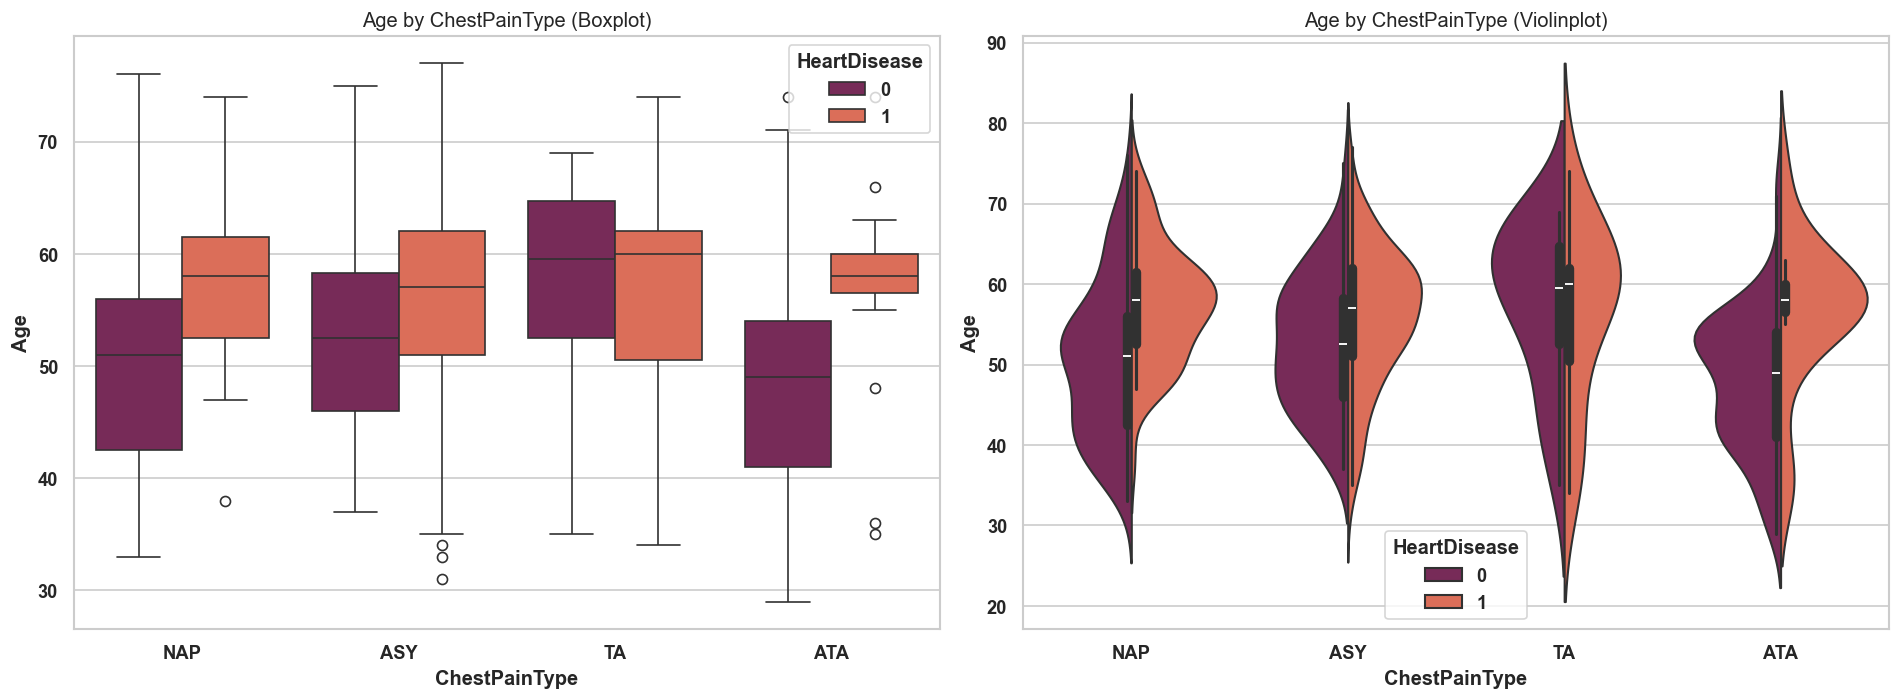

In [29]:
#Insight 8: How does Age and ChestPainType affect HeartDisease chances?
Analyse_NumtoCat(pd.concat([X_train, y_train], axis = 1), 'Age', 'ChestPainType')

💡 Key Insight: Age Distributions within Chest Pain Types
* **Consistent Onset:** The median age of patients diagnosed with heart disease is remarkably consistent (**~60 years**) across all chest pain categories.
* **Diagnostic Overlap:**
    * **High Overlap (TA & ASY):** For Typical Angina and Asymptomatic cases, the age distributions of healthy and unhealthy patients are very similar. This implies that **Age alone** is not a strong differentiator within these specific symptom groups.
    * **Clearer Separation (NAP):** In contrast, patients with Non-Anginal Pain (NAP) show distinct age separation, meaning older age is a more reliable predictor of disease in this specific group.

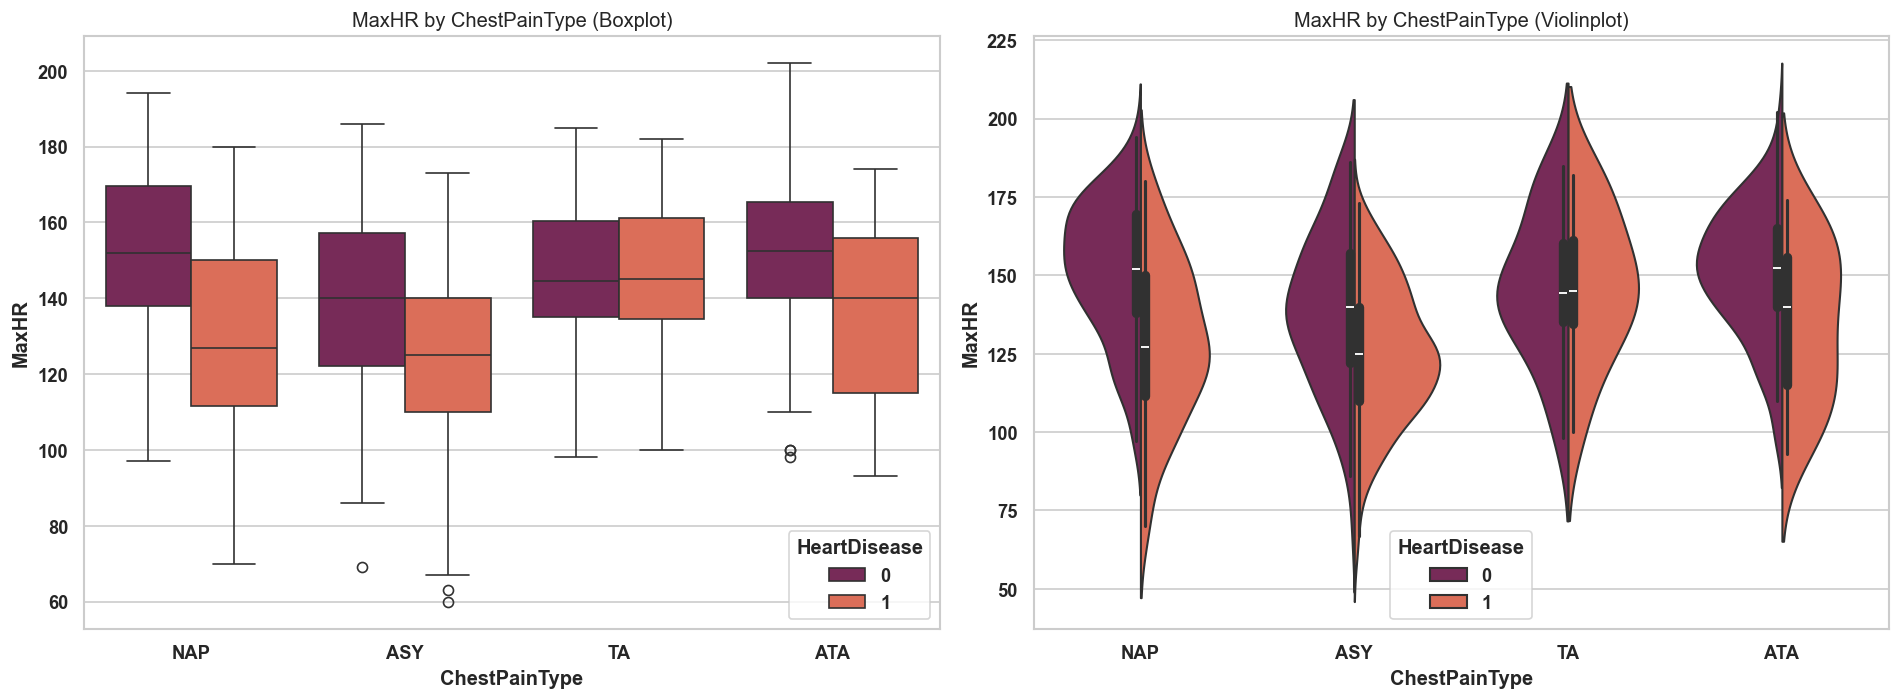

In [30]:
#Insight 9: How does MaxHR and ChestPainType affect HeartDisease chances?
Analyse_NumtoCat(pd.concat([X_train, y_train], axis = 1), 'MaxHR', 'ChestPainType')

💡 Key Insight: Heart Rate & Chest Pain Dynamics
* **The General Rule:** Across most categories, patients with heart disease exhibit a **significantly lower** Maximum Heart Rate (MaxHR) compared to healthy individuals.
    * **The Exception:** **Typical Angina (TA)** is the outlier. In this specific subgroup, unhealthy patients actually show a slightly *higher* median heart rate.
* **Peak Performance:** Healthy patients presenting with **Non-Anginal Pain (NAP)** record the highest median heart rates in the dataset (~150 bpm).
* **Diagnostic Challenge:** There is significant overlap in heart rates between healthy and unhealthy groups, particularly for Non-Anginal Pain. This overlap is even more pronounced in other pain types, indicating that MaxHR is a useful but not standalone predictor.

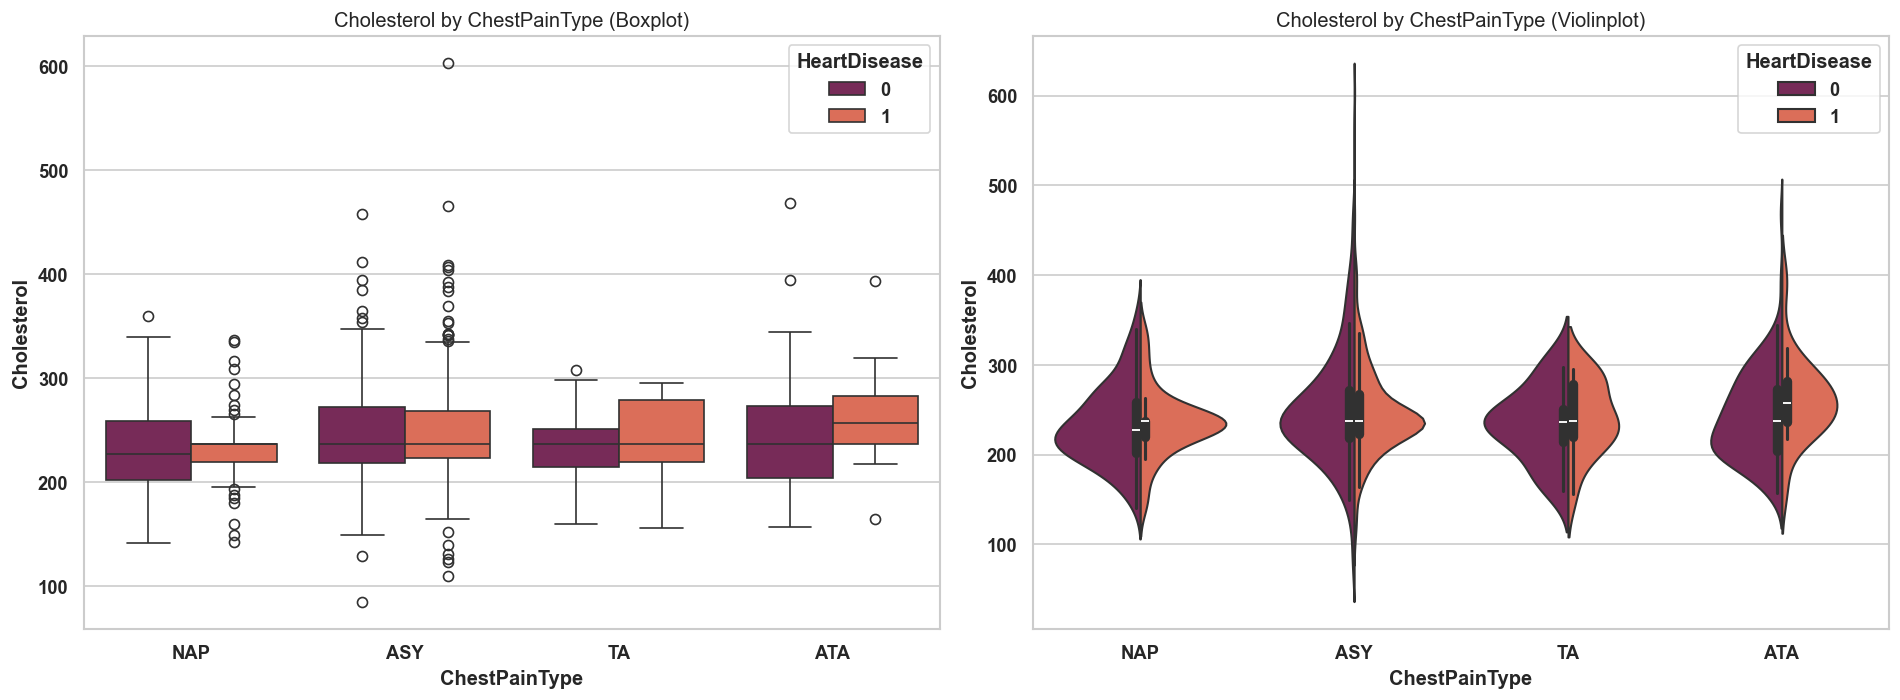

In [31]:
#Insight 10: How does Cholesterol and ChestPainType affect HeartDisease chances?
Analyse_NumtoCat(pd.concat([X_train, y_train], axis = 1), 'Cholesterol', 'ChestPainType')

💡 Key Insight: Cholesterol & Chest Pain Interaction
* **Uniform Baselines:** Surprisingly, the median cholesterol levels are remarkably consistent (**~225 mm/dl**) for both healthy and unhealthy patients, regardless of the chest pain type reported.
* **The Atypical Exception:** Patients with **Atypical Angina (ATA)** are the slight exception to this rule, where unhealthy individuals present with marginally higher cholesterol levels.
* **Diagnostic Limitation:** The extensive overlap in distributions suggests that **Cholesterol levels alone** are not a strong discriminator for heart disease within these specific chest pain categories.

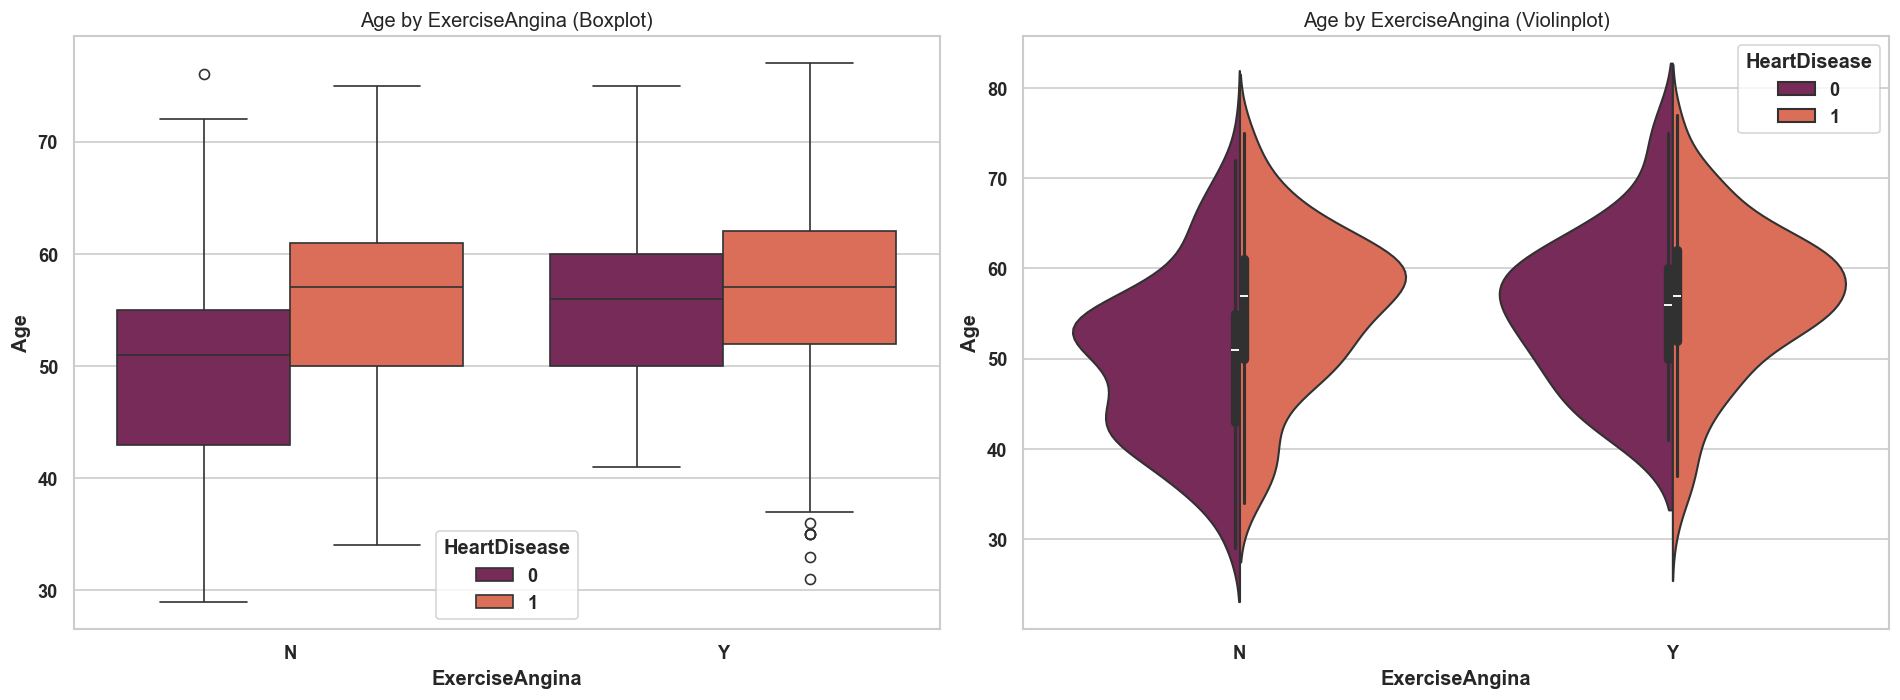

In [32]:
#Insight 11: How does Age and Exercise Angina affect HeartDisease chances?
Analyse_NumtoCat(pd.concat([X_train, y_train], axis = 1), 'Age', 'ExerciseAngina')

💡 Key Insight: Age & Exercise Angina Interaction
* **Strong Differentiator (No Angina):** For patients **without** exercise-induced angina, Age is a powerful predictor. Healthy individuals in this group are distinctly younger (median **~50 years**), offering clear separation from high-risk patients.
* **Weak Differentiator (With Angina):** When Exercise Angina is present, the diagnostic value of Age diminishes. There is significant overlap in the age distributions of healthy and unhealthy patients, suggesting that once Angina appears, age becomes less relevant as a standalone risk factor.

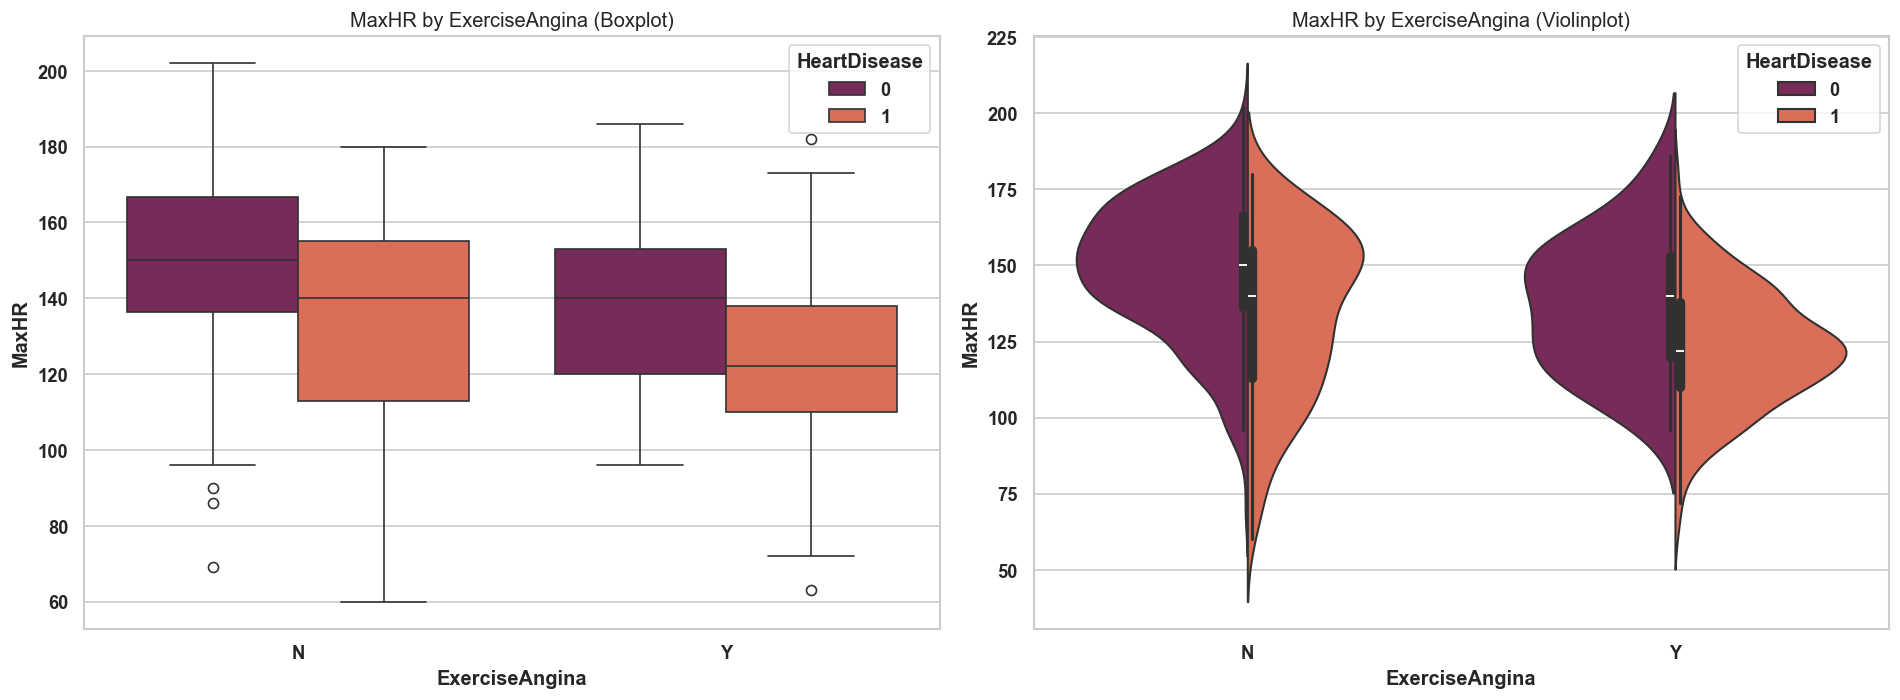

In [33]:
#Insight 12: How does MaxHR and Exercise Angina affect HeartDisease chances?
Analyse_NumtoCat(pd.concat([X_train, y_train], axis = 1), 'MaxHR', 'ExerciseAngina')

💡 Key Insight: Max Heart Rate & Exercise Angina
* **Physiological Ceiling (Healthy Group):** Healthy patients *without* exercise-induced angina demonstrate the highest cardiac reserve, achieving a median Max Heart Rate of **~150 bpm**. This sets the baseline for normal heart function under stress.
* **Functional Impairment (High Risk):** Conversely, patients *with* heart disease and exercise angina show a significantly reduced capacity, with a median MaxHR dropping to **~120 bpm**.
* **Diagnostic Overlap:** While the extremes (Healthy/No Angina vs. Sick/Angina) are distinct, there is considerable overlap in the intermediate groups. This suggests that while MaxHR is a useful indicator of severity, it must be interpreted alongside Angina symptoms for accurate diagnosis.

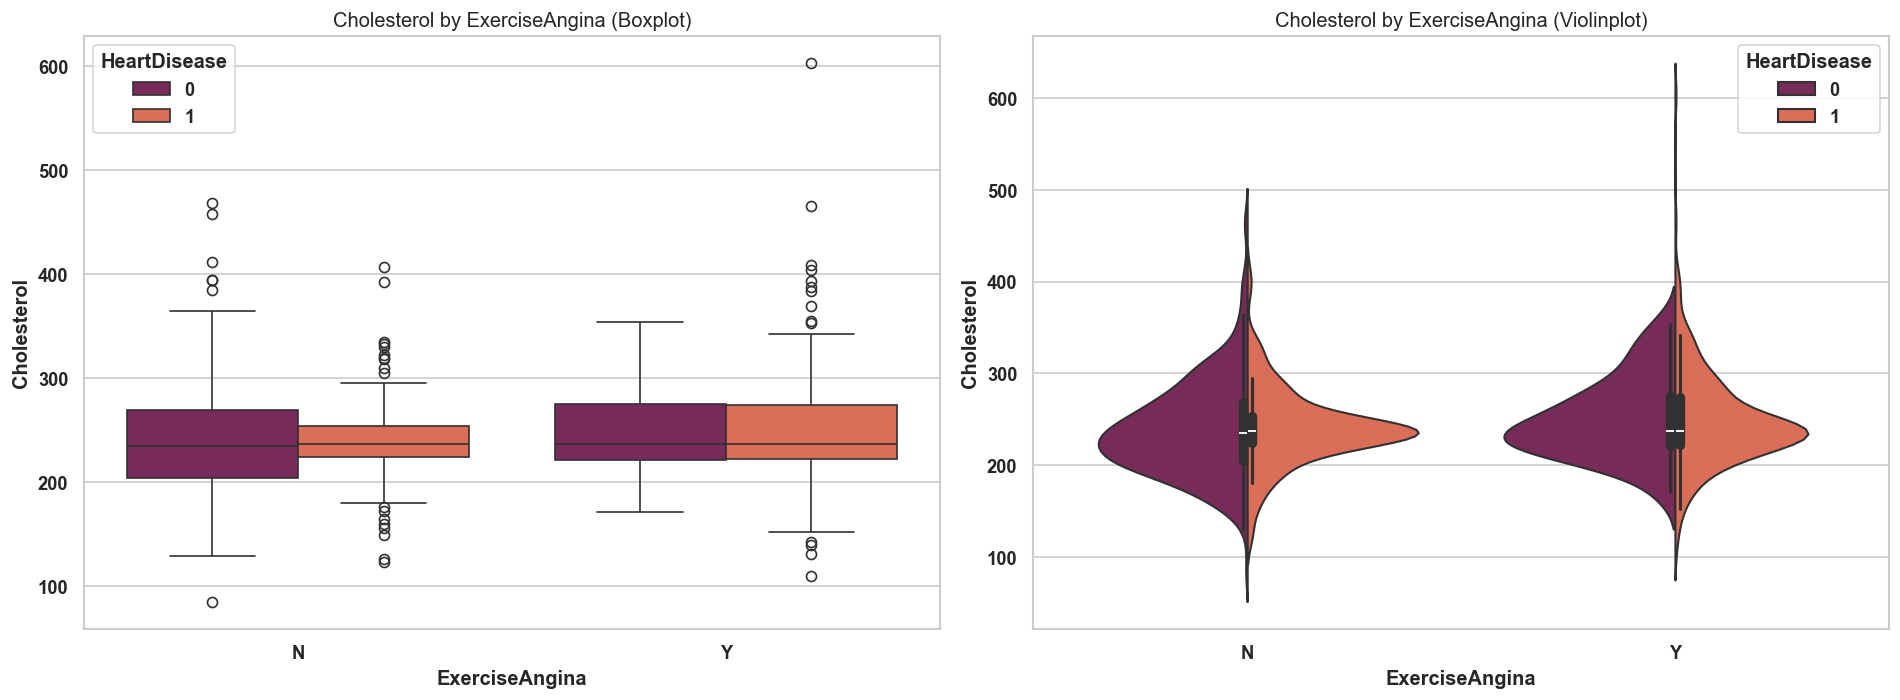

In [34]:
#Insight 13: How does Cholesterol and Exercise Angina affect HeartDisease chances?
Analyse_NumtoCat(pd.concat([X_train, y_train], axis = 1), 'Cholesterol', 'ExerciseAngina')

💡 Key Insight: Cholesterol & Exercise Angina
* **Uniform Profiles:** Analysis reveals that median cholesterol levels remain surprisingly similar across all groups, regardless of whether a patient experiences Exercise Angina.
* **Subtle Distinction:** While healthy individuals in each category exhibit *very slightly* lower median cholesterol, the difference is minimal.
* **Diagnostic Limitation:** The substantial overlap between healthy and unhealthy populations confirms that **Cholesterol**, in isolation, is a poor predictor of heart disease in this specific context.

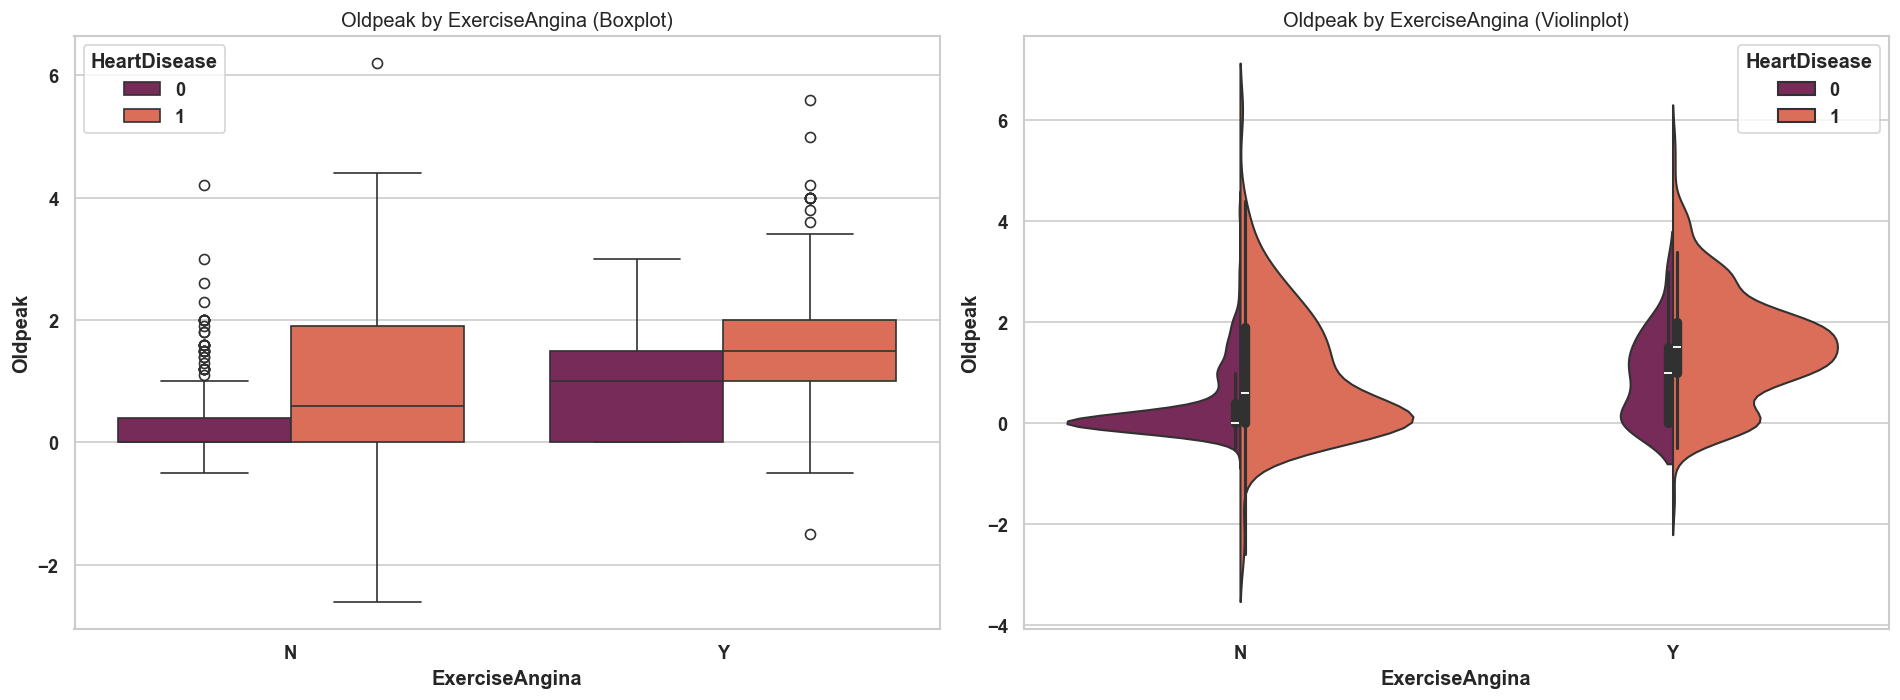

In [35]:
#Insight 14: How does Oldpeak and Exercise Angina affect HeartDisease chances?
Analyse_NumtoCat(pd.concat([X_train, y_train], axis = 1), 'Oldpeak', 'ExerciseAngina')

💡 Key Insight: Oldpeak & Exercise Angina Interaction
* **The Healthy Baseline:** For healthy patients *without* Exercise Angina, the median Oldpeak is **0**, indicating no ST depression relative to rest.
* **Significant Separation:** When Exercise Angina is present, the magnitude of ST depression becomes a critical discriminator.
    * **The Threshold:** The *median* Oldpeak for unhealthy patients is higher than the **75th percentile** of healthy patients.
    * **Implication:** This means that nearly half of the sick patients have Oldpeak values worse than the vast majority (top 25%) of healthy patients, making high Oldpeak in the presence of Angina a high-confidence signal for heart disease.

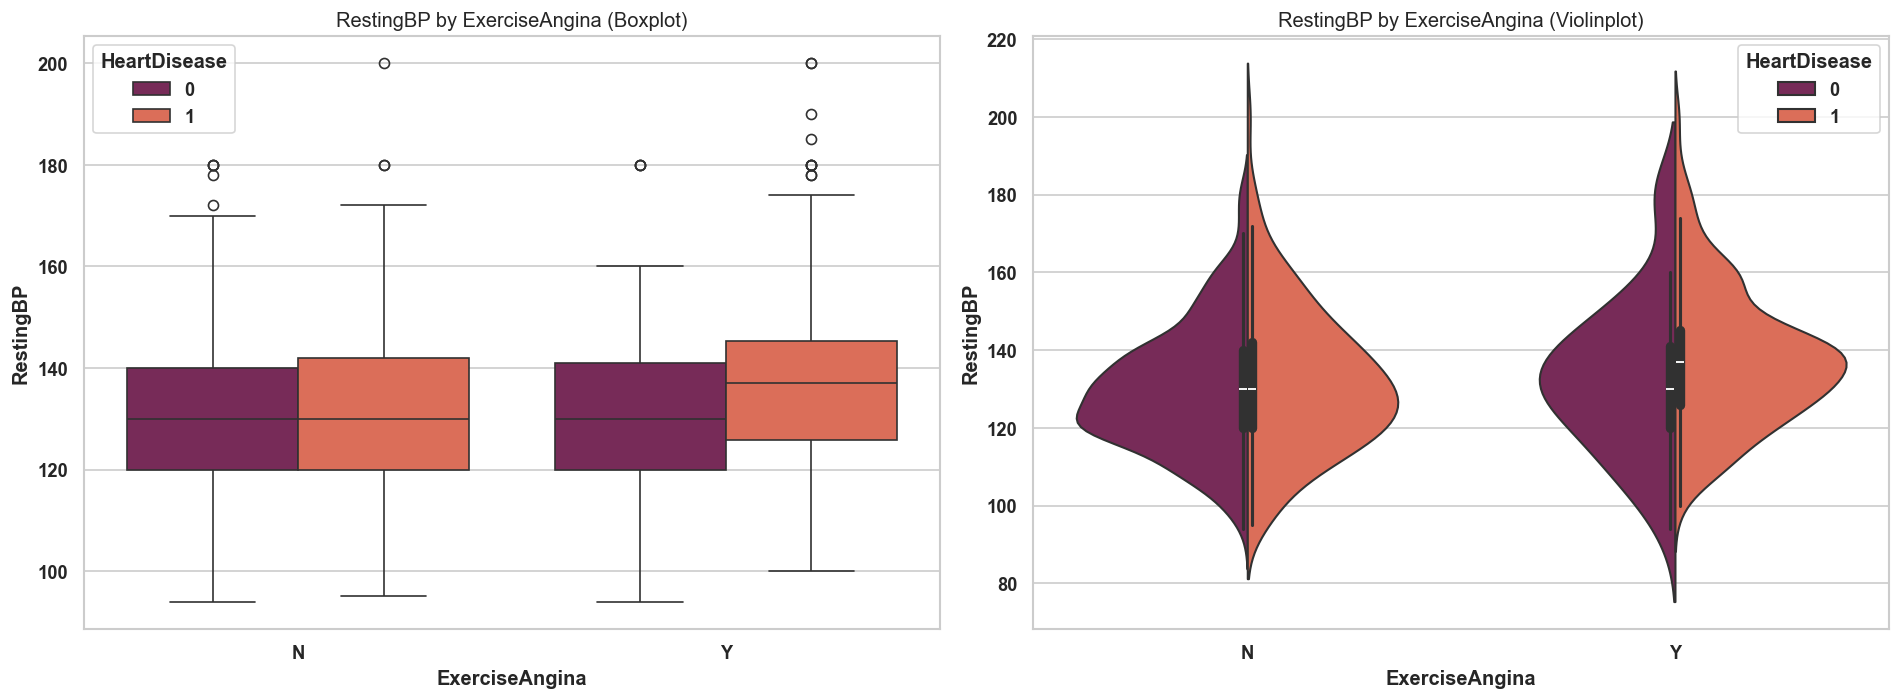

In [36]:
#Insight 15: How does RestingBP and Exercise Angina affect HeartDisease chances?
Analyse_NumtoCat(pd.concat([X_train, y_train], axis = 1), 'RestingBP', 'ExerciseAngina')

💡 Key Insight: Resting BP & Exercise Angina Interaction
* **The Healthy Baseline:** Interestingly, healthy individuals maintain a consistent median Resting Blood Pressure of **~130 mm Hg**, regardless of whether they experience exercise-induced angina.
* **The "Compound" Risk:**
    * **Moderate Elevation:** Unhealthy patients *without* angina show only a marginal increase in blood pressure above the baseline.
    * **Significant Spike:** The critical signal appears when **Exercise Angina** is present in unhealthy patients. In this group, the median Resting BP jumps significantly to **~140 mm Hg**.
* **Clinical Implication:** While there is general overlap across groups, a Resting BP approaching 140 mm Hg, specifically when combined with Exercise Angina, is a strong indicator of underlying heart disease.

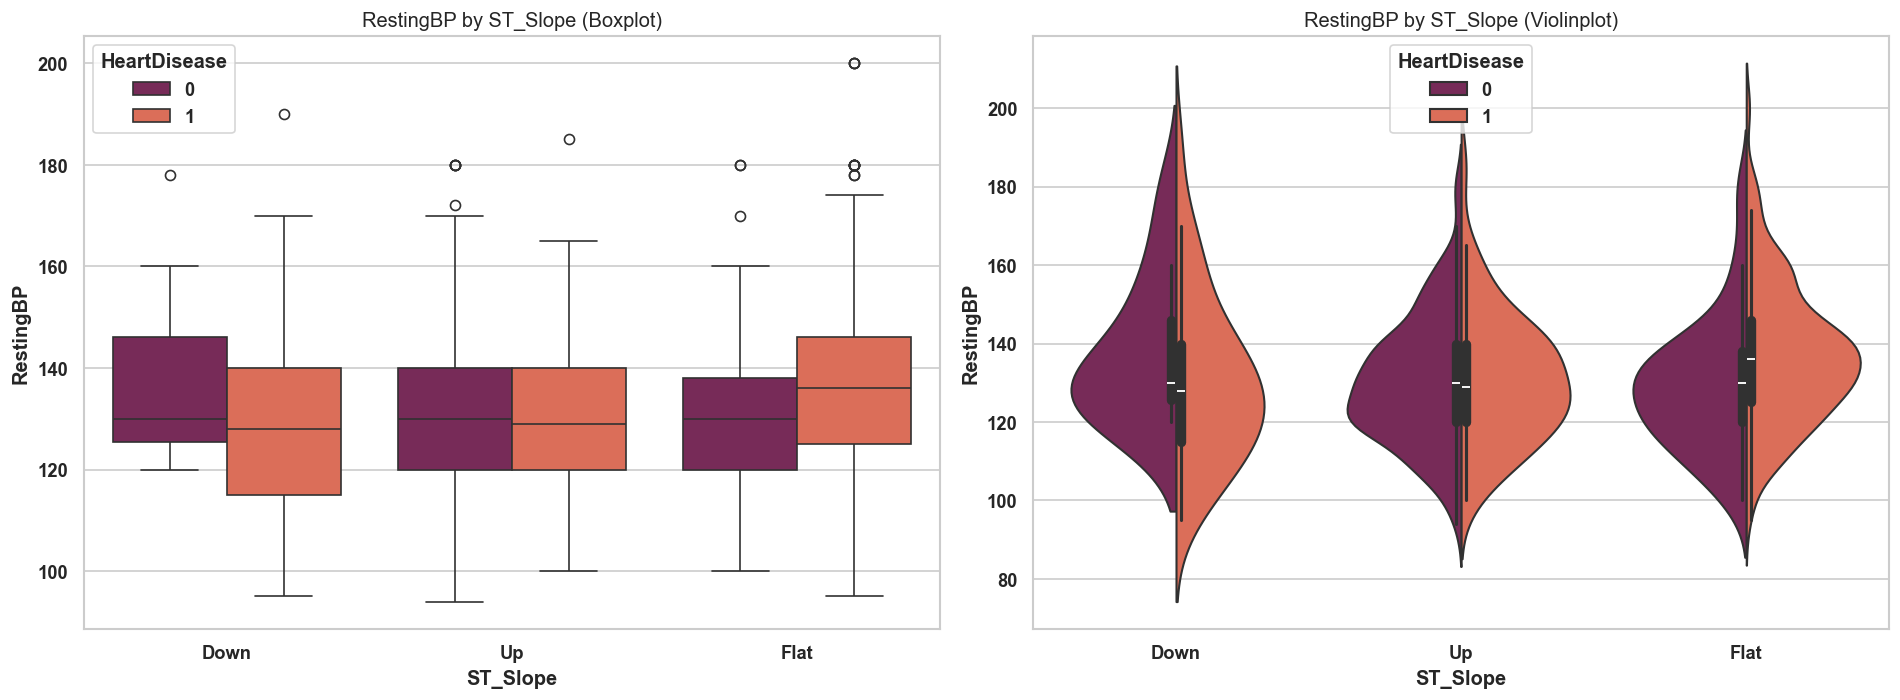

In [37]:
#Insight 16: How does RestingBP and ST_Slope affect HeartDisease chances?
Analyse_NumtoCat(pd.concat([X_train, y_train], axis = 1), 'RestingBP', 'ST_Slope')

💡 Key Insight: Resting BP & ST Slope Dynamics
* **Uniform Baseline (Up Slope):** For patients with an **Up** slope, the median Resting Blood Pressure is virtually identical (**~130 mm Hg**) for both healthy and unhealthy groups, offering no discriminatory value here.
* **Risk Divergence (Flat Slope):** The **Flat** slope category reveals a clearer pattern: unhealthy patients exhibit a noticeably higher median Blood Pressure compared to their healthy counterparts.
* **Statistical Anomaly (Down Slope):** In the **Down** slope group, healthy patients appear to have slightly higher BP. Given the small sample size of "Healthy + Down Slope" cases, this likely represents **sample noise** rather than a physiological rule.
* **Overall Overlap:** The significant overlap in Blood Pressure ranges across all slope types reinforces that Resting BP is a supportive feature, rather than a standalone diagnostic tool.

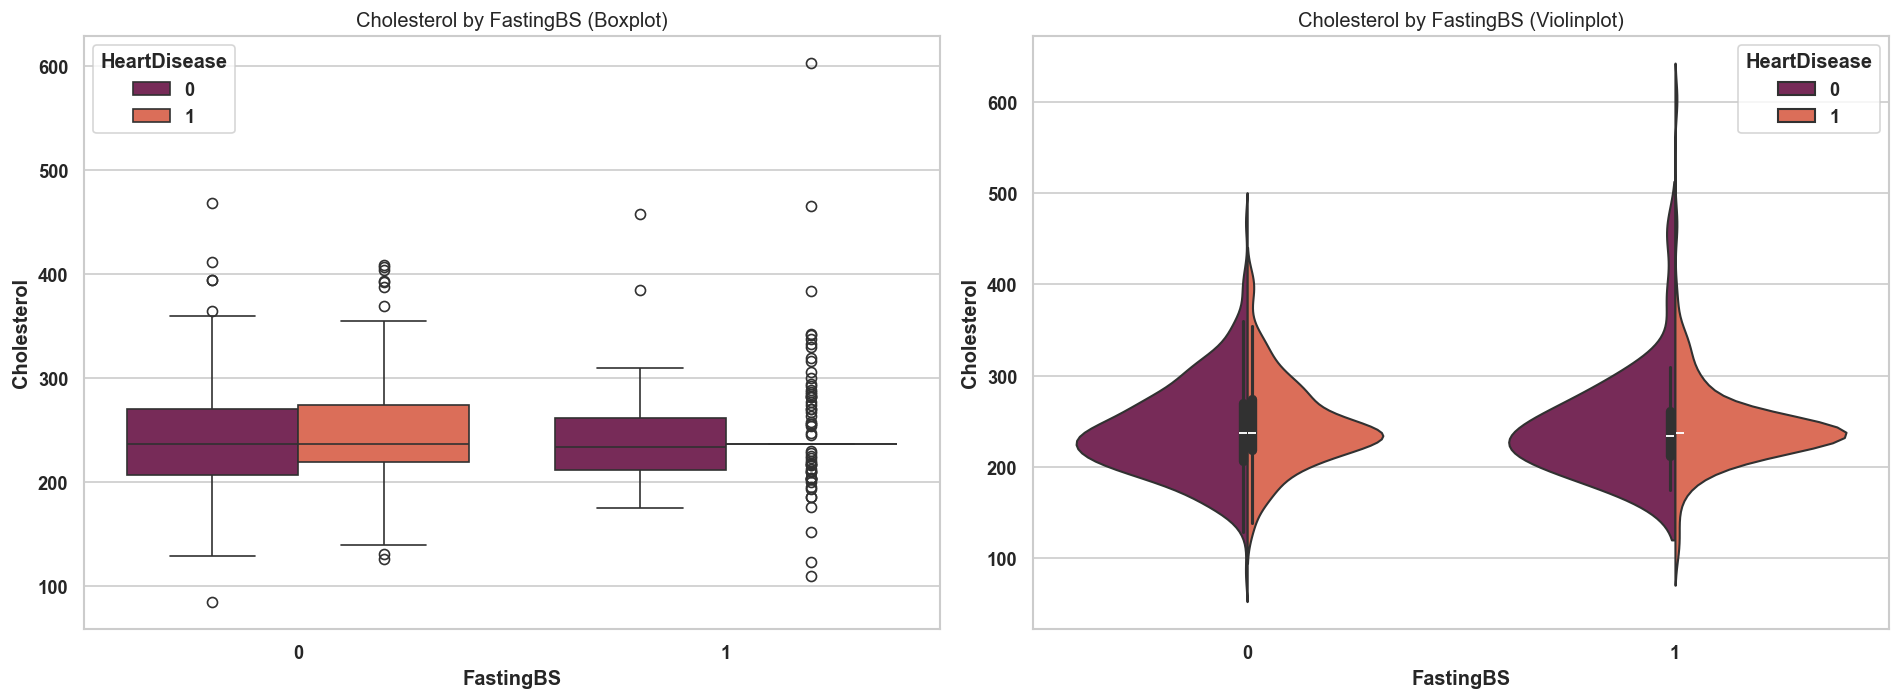

In [38]:
#Insight 17: How does Cholesterol and FastingBS affect HeartDisease chances?
Analyse_NumtoCat(pd.concat([X_train, y_train], axis = 1), 'Cholesterol', 'FastingBS')

💡 Key Insight: Cholesterol & Fasting Blood Sugar
* **Independent Risk Factors:** The relationship between Cholesterol and Heart Disease remains consistent, regardless of a patient's Fasting Blood Sugar level.
* **Marginal Elevation:** Unhealthy patients display only a **marginally higher** median cholesterol level compared to healthy patients.
* **Weak Separation:** The significant overlap in cholesterol distributions across both FastingBS groups (Normal vs. High) suggests that high blood sugar does not necessarily correlate with higher cholesterol in this specific cohort.

## Profiling

In [39]:
from ydata_profiling import ProfileReport
prof = ProfileReport(pd.concat([X_train, y_train], axis = 1))
prof.to_file('Heart_Disease_Profile_Report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 301.47it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Preprocessing

## 🛠️ Data Preprocessing Pipeline

We observed that features like `Oldpeak`, `Cholesterol`, and `RestingBP` are positively skewed. To maximize model performance, we apply the following transformations:

1.  **Skewed Numerical Data (`Oldpeak`, etc.):** Applied `PowerTransformer` (Yeo-Johnson) to normalize distributions, followed by `StandardScaler`.
2.  **Normal Numerical Data (`Age`, `MaxHR`):** Applied `StandardScaler` to ensure zero mean and unit variance.
3.  **Categorical Data:** Applied `OneHotEncoder` to convert nominal variables into machine-readable binary vectors.

This pipeline prevents data leakage by fitting *only* on `X_train` and transforming `X_test`.

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer

skewed_col = ['Oldpeak', 'Cholesterol', 'RestingBP']
normal_col = ['Age', 'MaxHR']

PT = PowerTransformer(method = 'yeo-johnson')
OHE = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
SS = StandardScaler()

skewed_transformer = Pipeline(steps=[('power_transform', PT), ('scaler', SS)])

preprocessor = ColumnTransformer([('skewed', skewed_transformer, skewed_col),
                                  ('numerical', SS, normal_col),
                                  ('categorical', OHE, cat_col)],
                                  remainder='passthrough')

In [41]:
preprocessor.fit(X_train)

,transformers,"[('skewed', ...), ('numerical', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,method,'yeo-johnson'
,standardize,True
,copy,True


In [42]:
transformed_X_train = preprocessor.transform(X_train)
transformed_X_test = preprocessor.transform(X_test)

# Modelling and Evaluation

In [43]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, accuracy_score

models = {'KNN': KNeighborsClassifier(),
          'LogisticRegression': LogisticRegression(),
          'NaiveBayes': GaussianNB(),
          'SVM': SVC(),
          'DecisionTree': DecisionTreeClassifier(),
          'Random Forest': RandomForestClassifier()}


def train_eval(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    cv_score = cross_val_score(model, X_train, y_train, cv = 5).mean()
    acc_score = accuracy_score(y_test, y_pred)
    
    print(f'{model_name} results:')
    print(f'% Accuracy : {acc_score*100}')
    print(f'% CV_Mean_Accuracy : {cv_score*100}')
    print('Classification Report :\n')
    print(classification_report(y_test, y_pred))
    print('-'*50 + '\n')

    return acc_score, cv_score

KNN results:
% Accuracy : 86.41304347826086
% CV_Mean_Accuracy : 85.42260739912402
Classification Report :

              precision    recall  f1-score   support

           0       0.82      0.87      0.84        77
           1       0.90      0.86      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184

--------------------------------------------------

LogisticRegression results:
% Accuracy : 86.41304347826086
% CV_Mean_Accuracy : 84.87373031404341
Classification Report :

              precision    recall  f1-score   support

           0       0.81      0.88      0.84        77
           1       0.91      0.85      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.87      0.86       184
weighted avg       0.87      0.86      0.86       184

--------------------------------------------------

NaiveBayes 

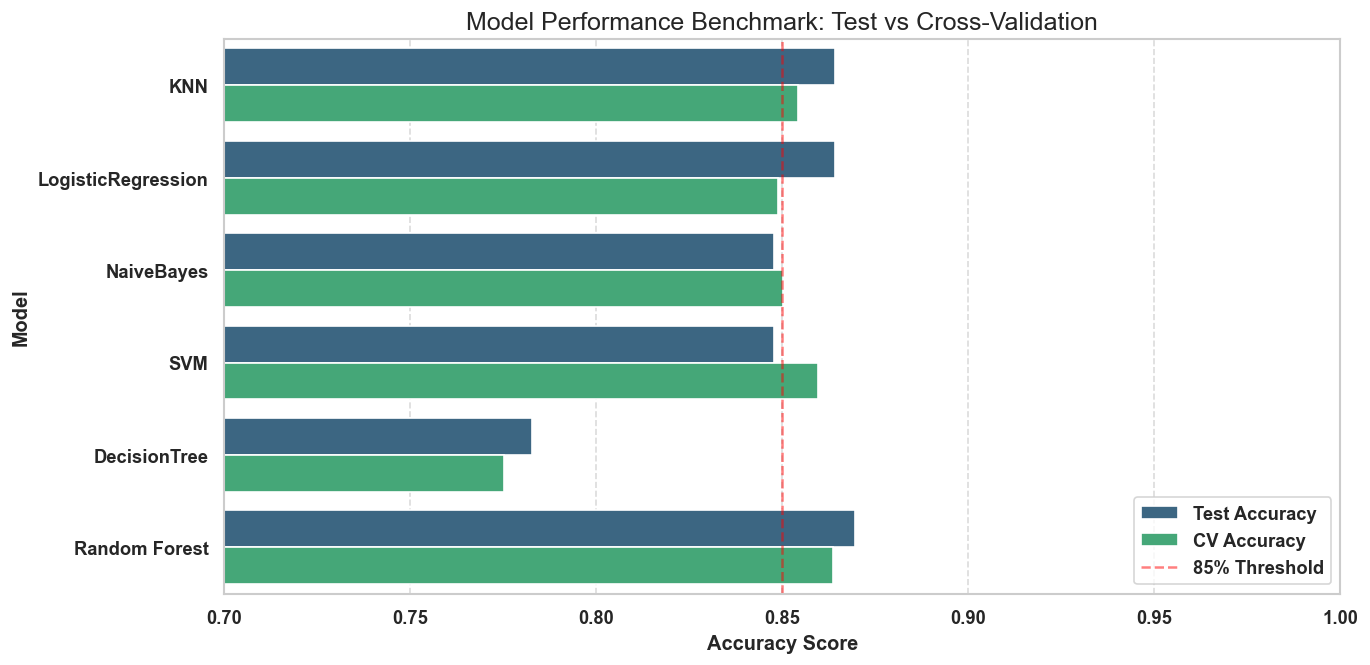

In [44]:
results_data = []

for model_name, model in models.items():
    acc, cv = train_eval(model_name, model, transformed_X_train, transformed_X_test, y_train, y_test)
    
    results_data.append({
        'Model': model_name,
        'Test Accuracy': acc,
        'CV Accuracy': cv
    })

df_results = pd.DataFrame(results_data)

plt.figure(figsize=(12, 6))

df_melted = df_results.melt(id_vars='Model', var_name='Metric', value_name='Score')

sns.barplot(data=df_melted, x='Score', y='Model', hue='Metric', palette='viridis')

plt.title('Model Performance Benchmark: Test vs Cross-Validation', fontsize=15)
plt.xlabel('Accuracy Score', fontsize=12)
plt.xlim(0.7, 1.0)
plt.axvline(0.85, color='red', linestyle='--', alpha=0.5, label='85% Threshold')
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()